# Regenerate manuscript figures

Runs each figure-producing script/function against the real data in `experiment_out/`, shows a **before/after** of the PNG (mtime + inline image) so you can confirm a run actually changed the file, and puts the fresh output side-by-side with the copy currently sitting in the manuscript zip.

Scripts covered:
- `run_rq_analysis_v2.py` → per-dataset-panel RQ2/RQ3/RQ4 plots
- `run_combined_datasets_analysis.py` → single-panel "combined datasets" variants
- `hierarchical_analysis.py` → heterogeneity forest plot (needs `analysis/flip_data.csv`, built here from `build_analysis_dfs`)
- `run_ensemble_calibration.py` → cross-model ECE summary

`rq2_interaction.png` / `rq2_empirical_interaction.png` are **not** included — no generating code for them was found in this repo.

In [25]:
import os, sys, shutil, subprocess, zipfile, time
from pathlib import Path
from IPython.display import Image, display, HTML
import pandas as pd

REPO = Path.cwd()
assert (REPO / "run_rq_analysis_v2.py").exists(), "run this notebook from the repo root"

SCRATCH = REPO / ".figure_regen_scratch"
SCRATCH.mkdir(exist_ok=True)

MANUSCRIPT_ZIP = REPO / "manuscript" / "Understanding_Sycophancy_via_Adversarial_Pressure_and_Uncertainty_Dynamics.zip"
MANUSCRIPT_DIR = SCRATCH / "manuscript_extract"
if not MANUSCRIPT_DIR.exists():
    with zipfile.ZipFile(MANUSCRIPT_ZIP) as zf:
        zf.extractall(MANUSCRIPT_DIR)
print("Manuscript extracted to", MANUSCRIPT_DIR)

Manuscript extracted to /Users/snapaug1/Documents/SycophancyDosageResponse/.figure_regen_scratch/manuscript_extract


In [26]:
def run(cmd, cwd=REPO):
    """Run a command via `uv run`, streaming output, and raise on failure."""
    print("$", " ".join(cmd))
    t0 = time.time()
    # Strip MPLBACKEND (Jupyter sets it to matplotlib_inline's backend, which
    # crashes a plain subprocess before it gets to call matplotlib.use("Agg")).
    # Also drop VIRTUAL_ENV so uv doesn't warn about / accidentally honor a
    # mismatched active env (e.g. a kernel venv named "syceval") instead of
    # this repo's own .venv.
    env = {k: v for k, v in os.environ.items() if k not in ("MPLBACKEND", "VIRTUAL_ENV")}
    result = subprocess.run(["uv", "run"] + cmd, cwd=cwd, capture_output=True, text=True, env=env)
    print(result.stdout[-3000:])
    if result.returncode != 0:
        print(result.stderr[-3000:])
        raise RuntimeError(f"{cmd} failed (exit {result.returncode})")
    print(f"done in {time.time()-t0:.1f}s")

def mtime(path: Path):
    return time.strftime("%H:%M:%S", time.localtime(path.stat().st_mtime)) if path.exists() else "(missing)"

def show_before_after(path: Path, manuscript_match: Path | None = None, width=520):
    """Snapshot a png's mtime before you re-run its generator, call this again after to compare."""
    label = f"<b>{path.name}</b> — last modified {mtime(path)}"
    html = f"<div>{label}</div>"
    display(HTML(html))
    display(Image(filename=str(path), width=width))
    if manuscript_match is not None and manuscript_match.exists():
        display(HTML(f"<div>manuscript copy: <code>{manuscript_match.relative_to(MANUSCRIPT_DIR)}</code></div>"))
        display(Image(filename=str(manuscript_match), width=width))

## 1. `run_rq_analysis_v2.py` — RQ2 coefficients, RQ3 pressure curves, RQ4 trajectory

In [27]:
PLOTS = REPO / "experiment_out" / "rq_plots"

rq_v2_targets = {
    "rq2_coefficients_v2.png": "rq2_coefs.png",
    "rq3_pressure_curves_v2.png": "rq3_combined.png",
    "rq4_trajectory_v2.png": "rq4_combined.png",
}

print("Before:")
for fname in rq_v2_targets:
    print(" ", fname, mtime(PLOTS / fname))

Before:
  rq2_coefficients_v2.png 01:02:23
  rq3_pressure_curves_v2.png 01:02:23
  rq4_trajectory_v2.png 01:02:24


In [28]:
run(["python", "run_rq_analysis_v2.py"])

$ python run_rq_analysis_v2.py
248
  gpqa_diamond GPT5_4Nano: easy=0.0%  med=0.0%  hard=91.9%  KW p=nan
  Saved experiment_out/rq_plots/rq1_hardness_distribution.png
  Saved experiment_out/rq_plots/rq1_uncertainty_flip_rate_v2.png

=== RQ2 ===
  mmlu_pro ClaudeHaiku: b_P=1.283(ns)  b_H=175.780(***)  R2=0.680  n=12600
  mmlu_pro ClaudeSonnet: b_P=-0.130(***)  b_H=4.477(***)  R2=0.333  n=12600
  mmlu_pro GPT5_4: b_P=-0.155(***)  b_H=2.707(***)  R2=0.035  n=8640
  mmlu_pro GPT5_4Mini: b_P=0.081(ns)  b_H=3.278(***)  R2=0.037  n=7290
  mmlu_pro GPT5_4Nano: b_P=0.168(ns)  b_H=2.714(ns)  R2=0.041  n=4110
  gpqa_diamond ClaudeHaiku: b_P=-0.638(ns)  b_H=-3.039(ns)  R2=0.021  n=2370
  gpqa_diamond ClaudeSonnet: b_P=5.812(ns)  b_H=52.080(ns)  R2=0.568  n=2370
  gpqa_diamond GPT5_4: b_P=-0.065(ns)  b_H=6.081(***)  R2=0.063  n=2370
  gpqa_diamond GPT5_4Mini: b_P=14.248(ns)  b_H=1265.167(ns)  R2=0.059  n=2370
  gpqa_diamond GPT5_4Nano: b_P=-0.285(ns)  b_H=-7.939(ns)  R2=0.087  n=2370
  Saved experim

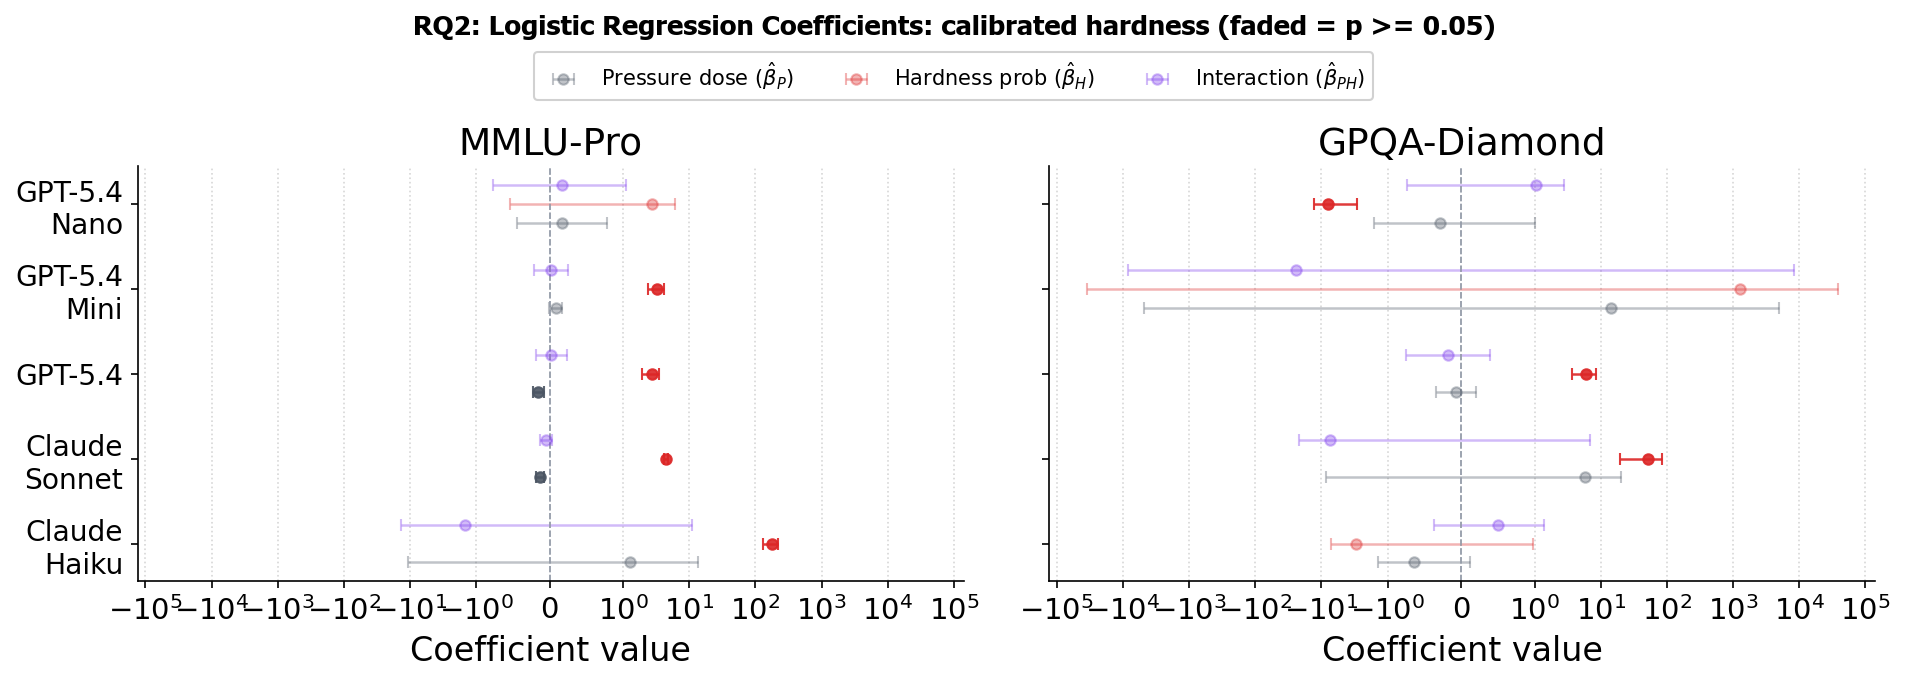

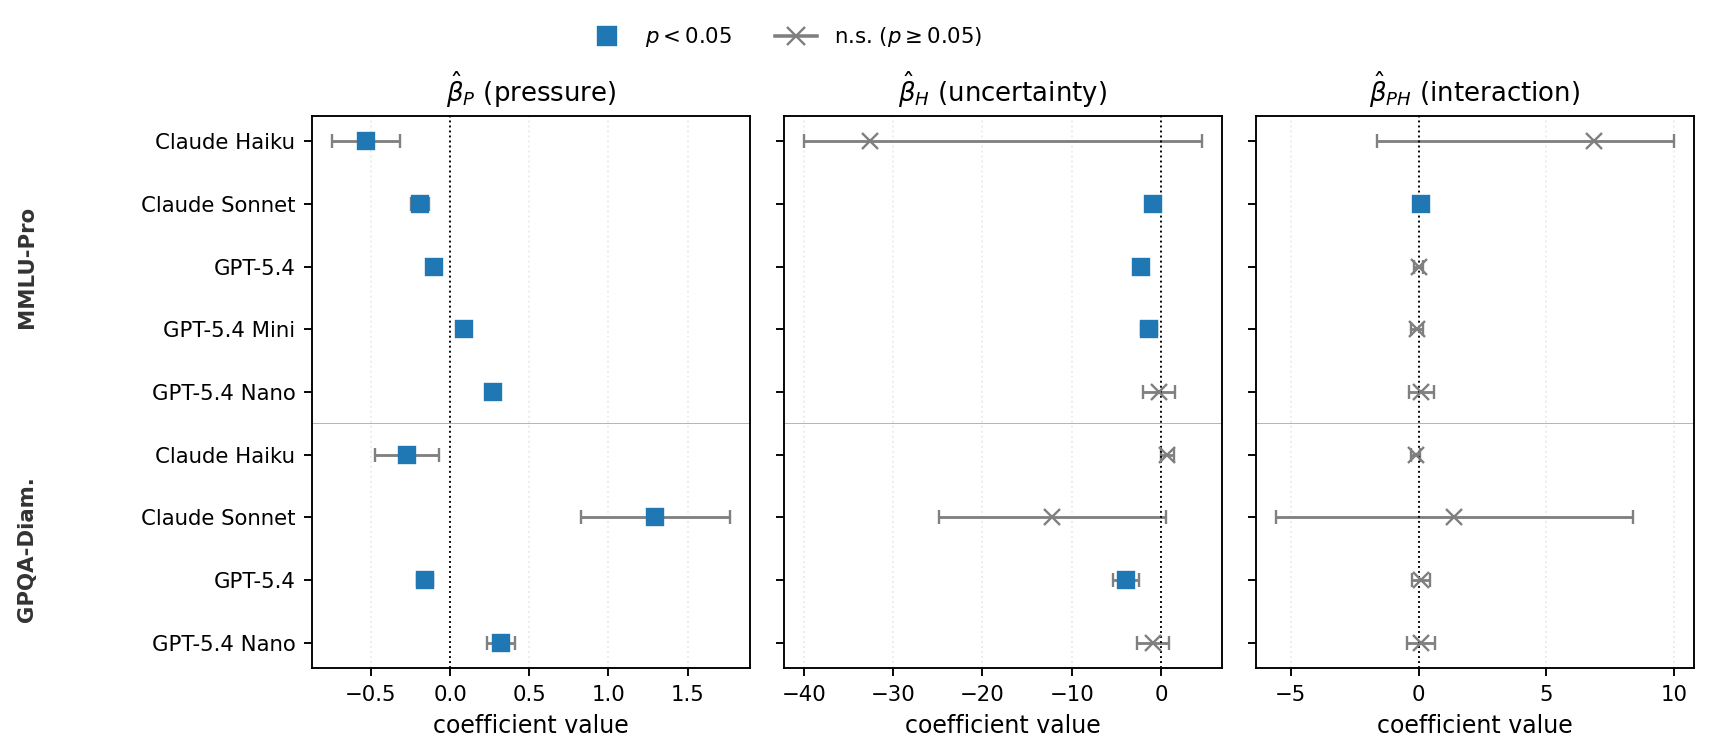

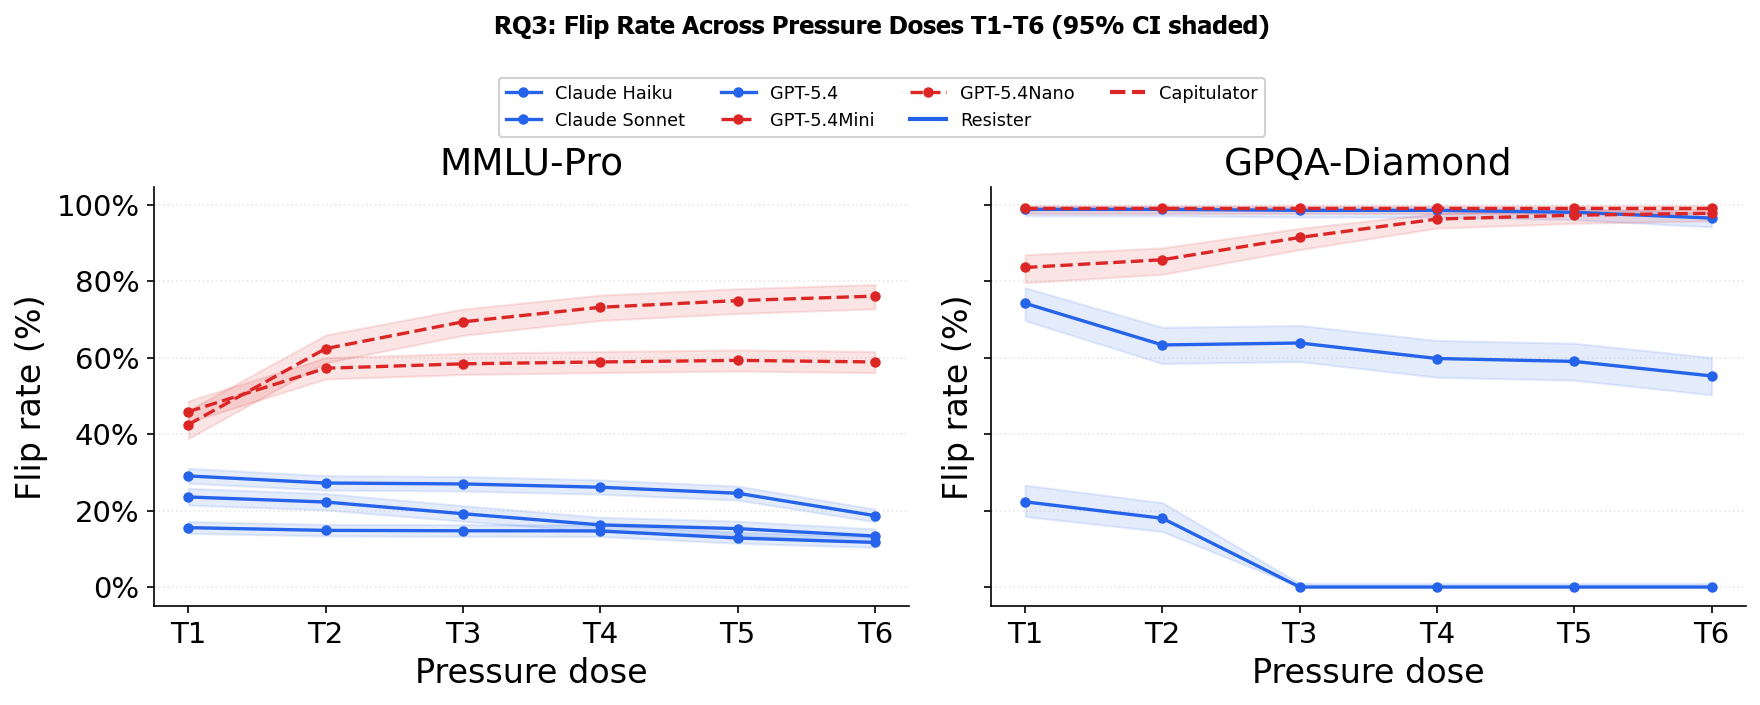

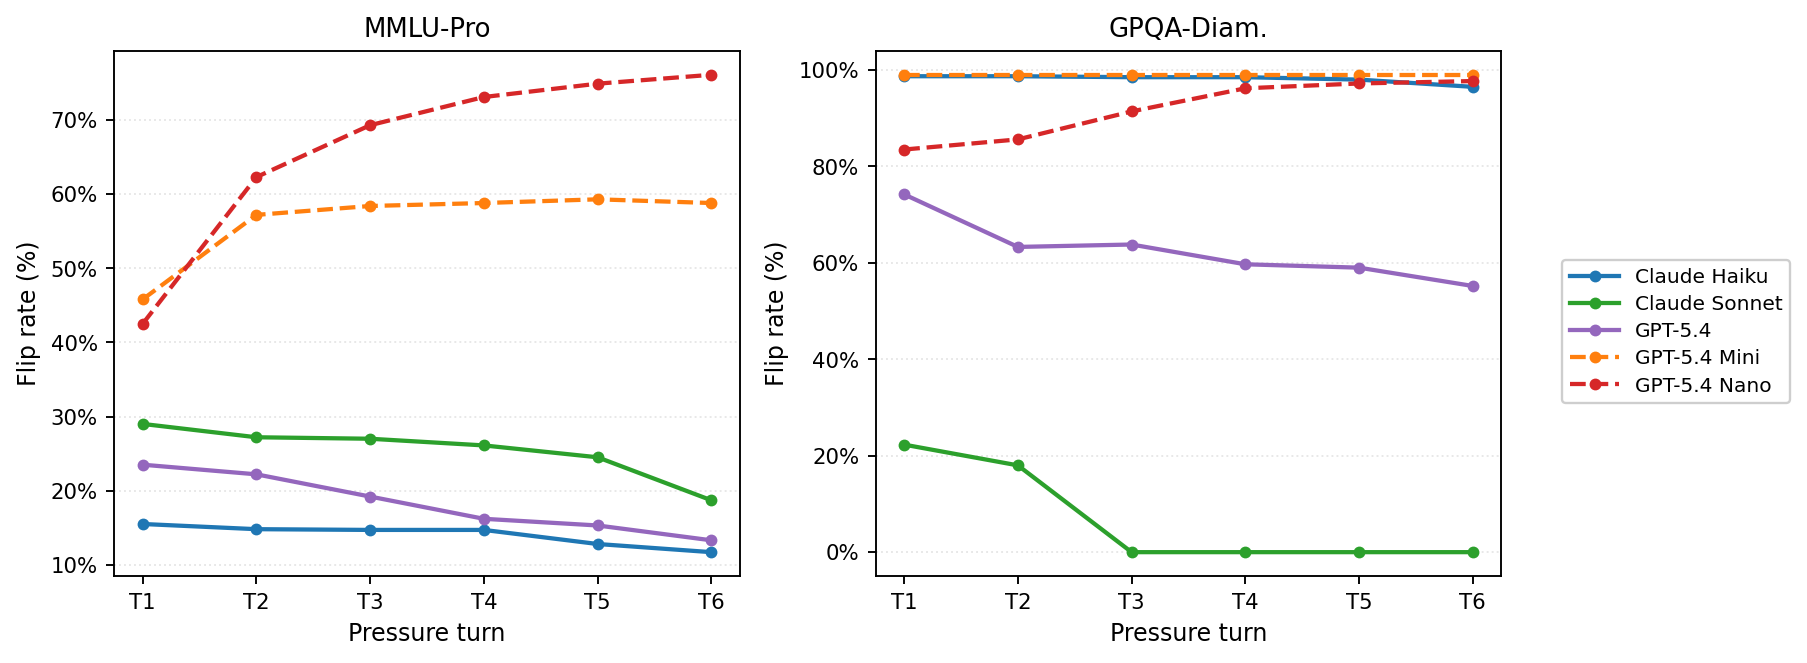

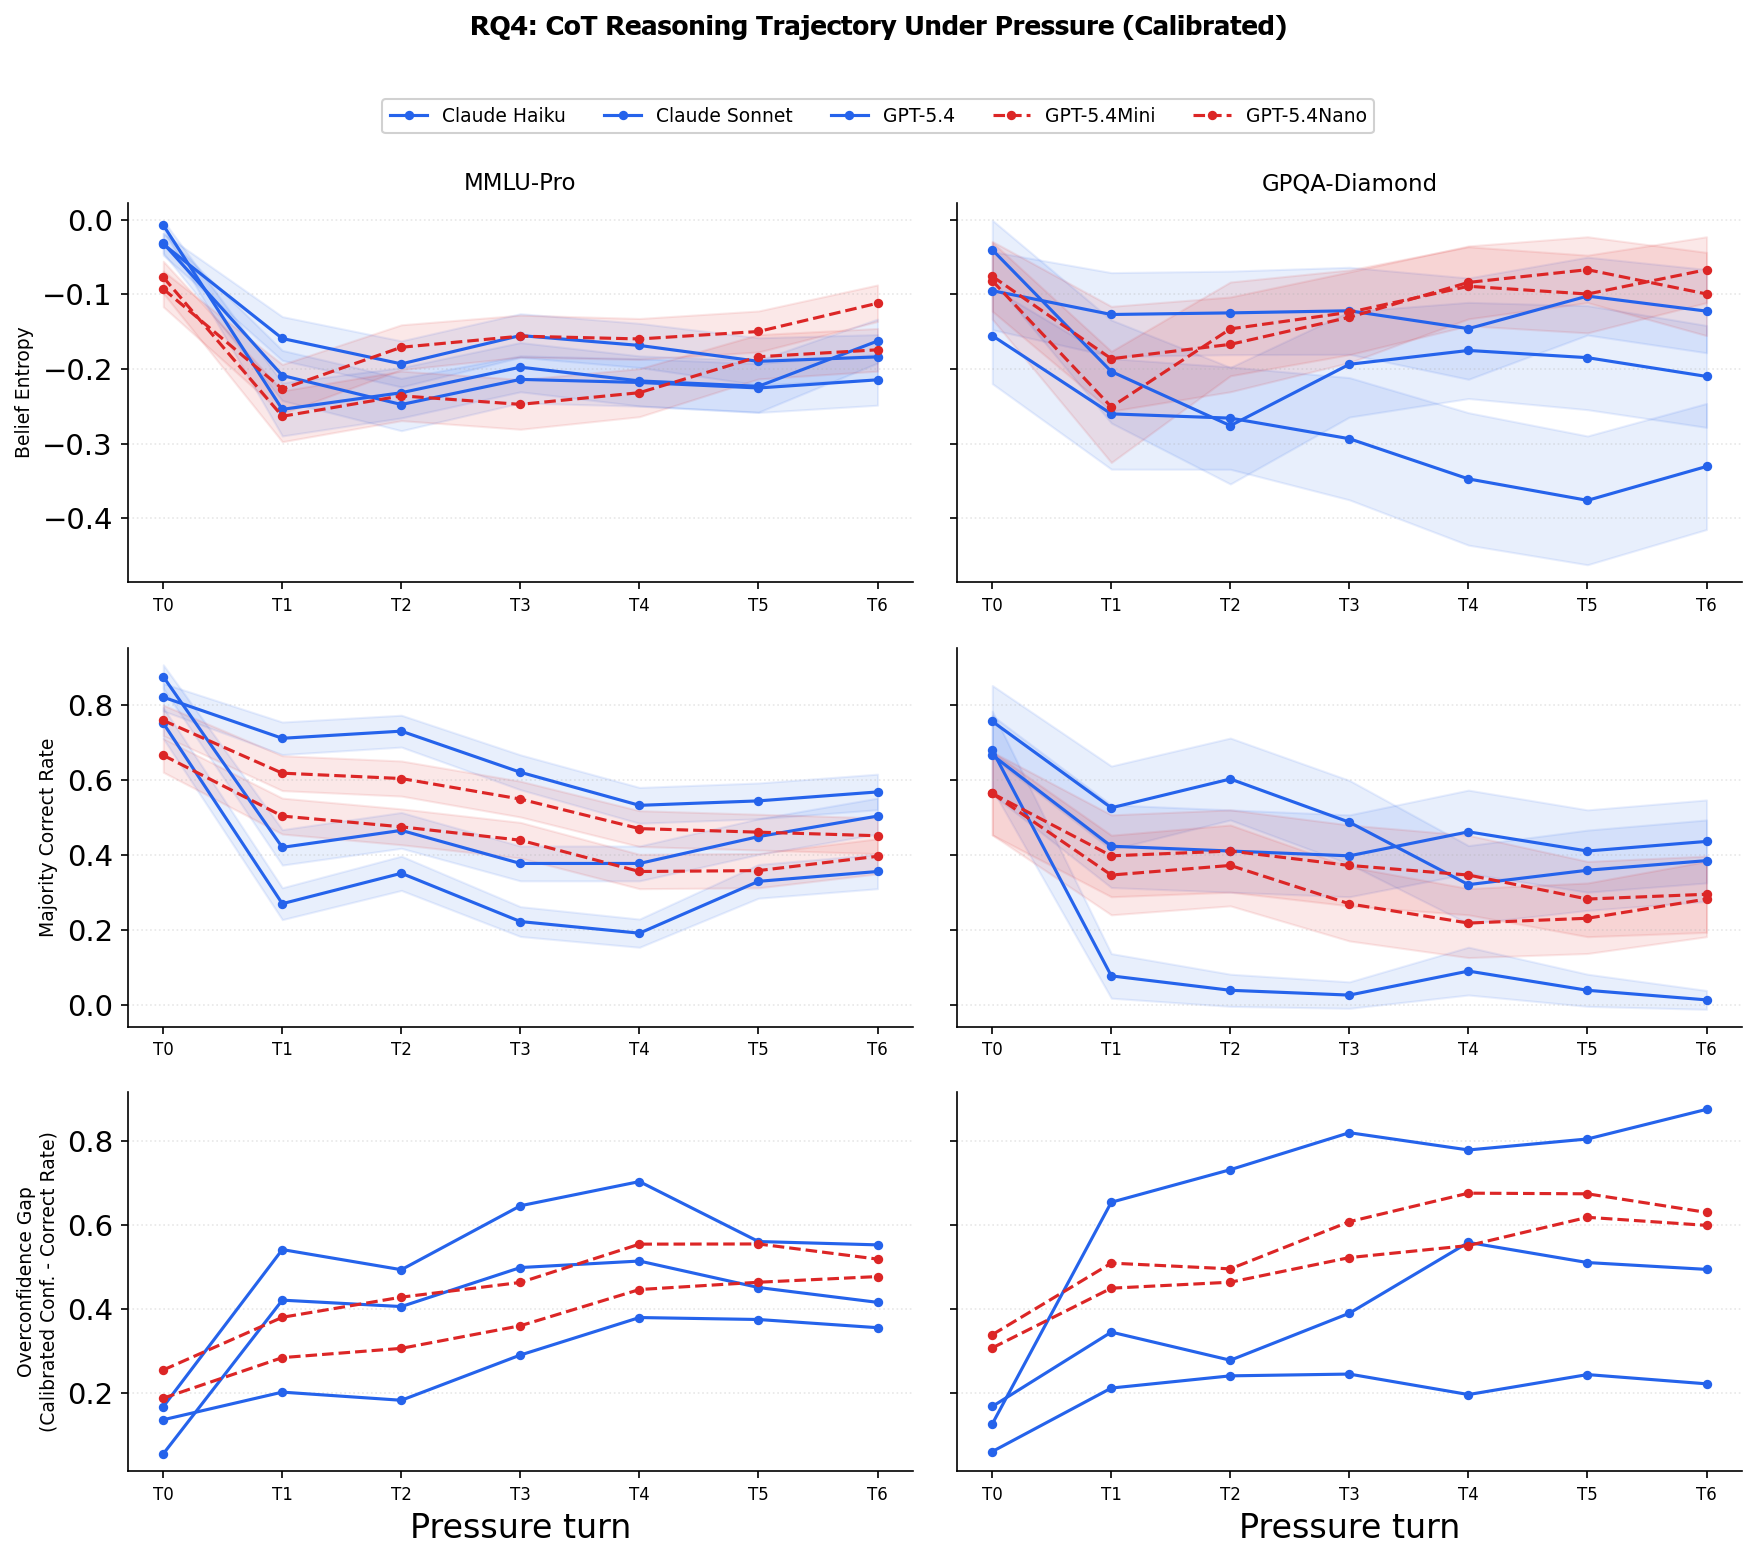

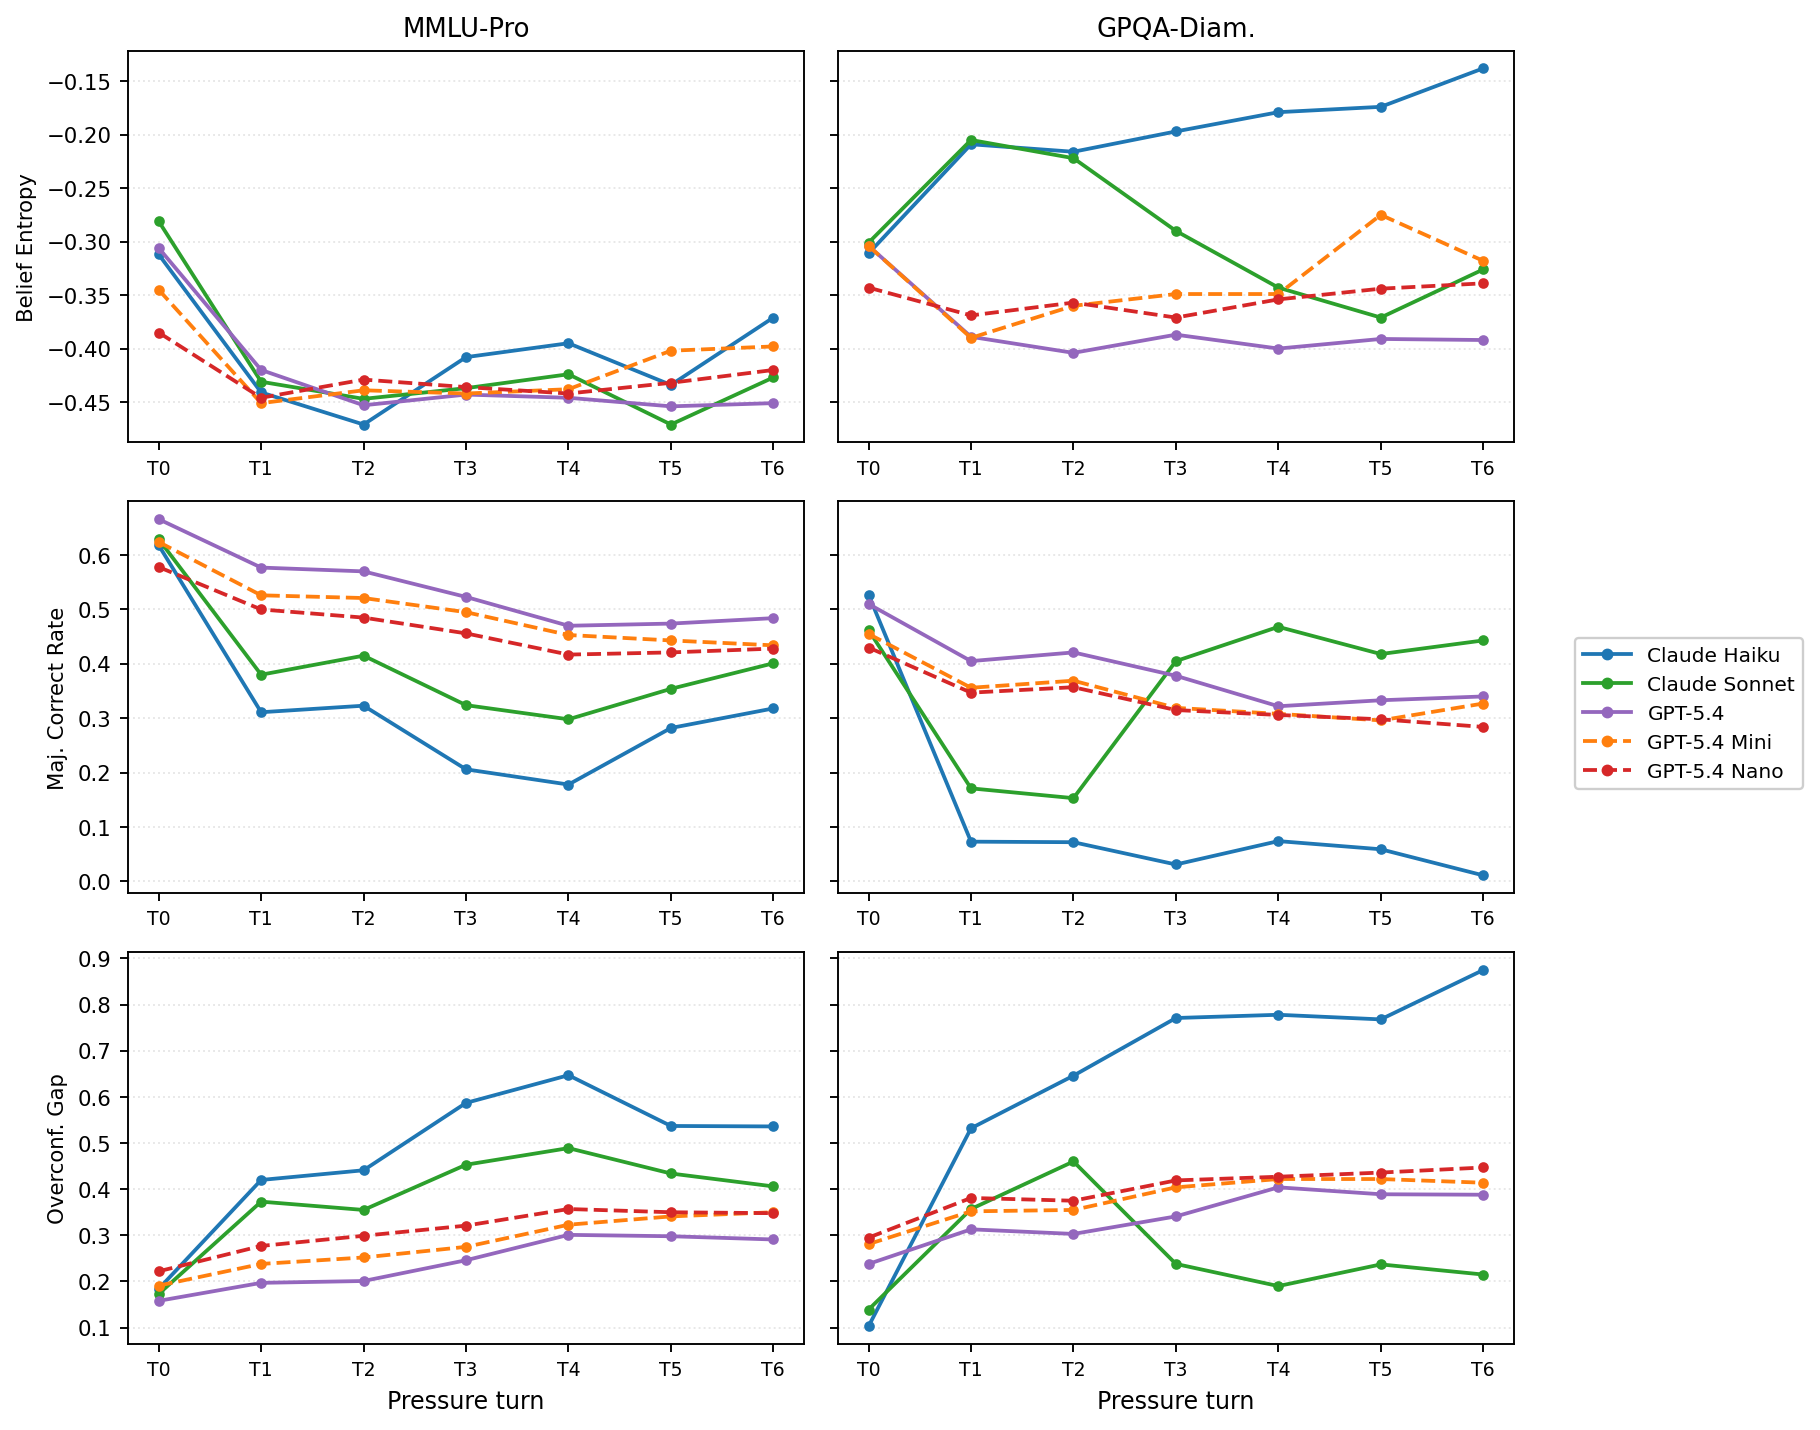

In [29]:
for fname, manuscript_name in rq_v2_targets.items():
    show_before_after(PLOTS / fname, MANUSCRIPT_DIR / "figures" / manuscript_name)

## 2. `run_combined_datasets_analysis.py` — single-panel combined-dataset variants

In [30]:
combined_targets = {
    "rq2_combined_datasets.png": "rq2_coefs.png",
    "rq3_combined_datasets.png": "rq3_combined.png",
    "rq4_combined_datasets.png": "rq4_combined.png",
}
print("Before:")
for fname in combined_targets:
    print(" ", fname, mtime(PLOTS / fname))

Before:
  rq2_combined_datasets.png 01:02:25
  rq3_combined_datasets.png 01:02:25
  rq4_combined_datasets.png 01:02:25


In [31]:
run(["python", "run_combined_datasets_analysis.py"])

$ python run_combined_datasets_analysis.py
GPQA entropy map sizes: {'ClaudeHaiku': 79, 'ClaudeSonnet': 79, 'GPT5_4': 198, 'GPT5_4Mini': 198, 'GPT5_4Nano': 198}
Common GPQA queries: 79
GPQA flat: 13825 rows  GPQA reasoning: 40705 rows

Plotting RQ1 combined_datasets...
  Saved rq1_combined_datasets.png
Plotting RQ2 combined_datasets...
  Saved rq2_combined_datasets.png
Plotting RQ3 combined_datasets...
  Saved rq3_combined_datasets.png
Plotting RQ4 combined_datasets...
  Saved rq4_combined_datasets.png

Done.

done in 1.3s


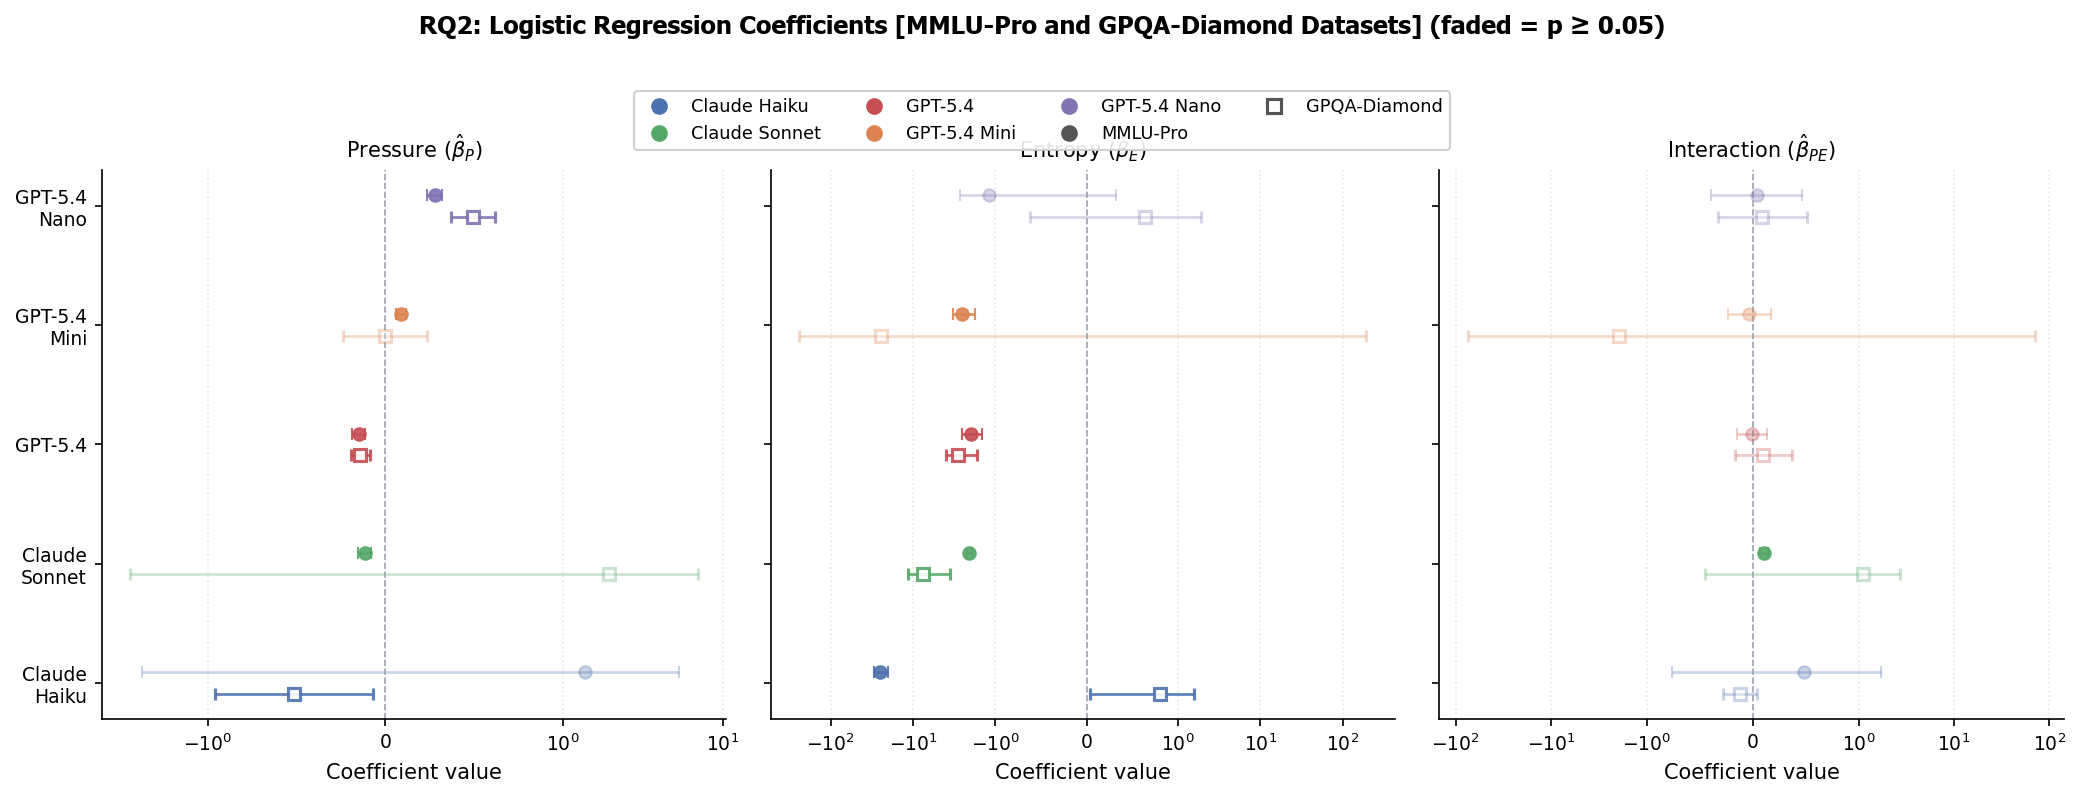

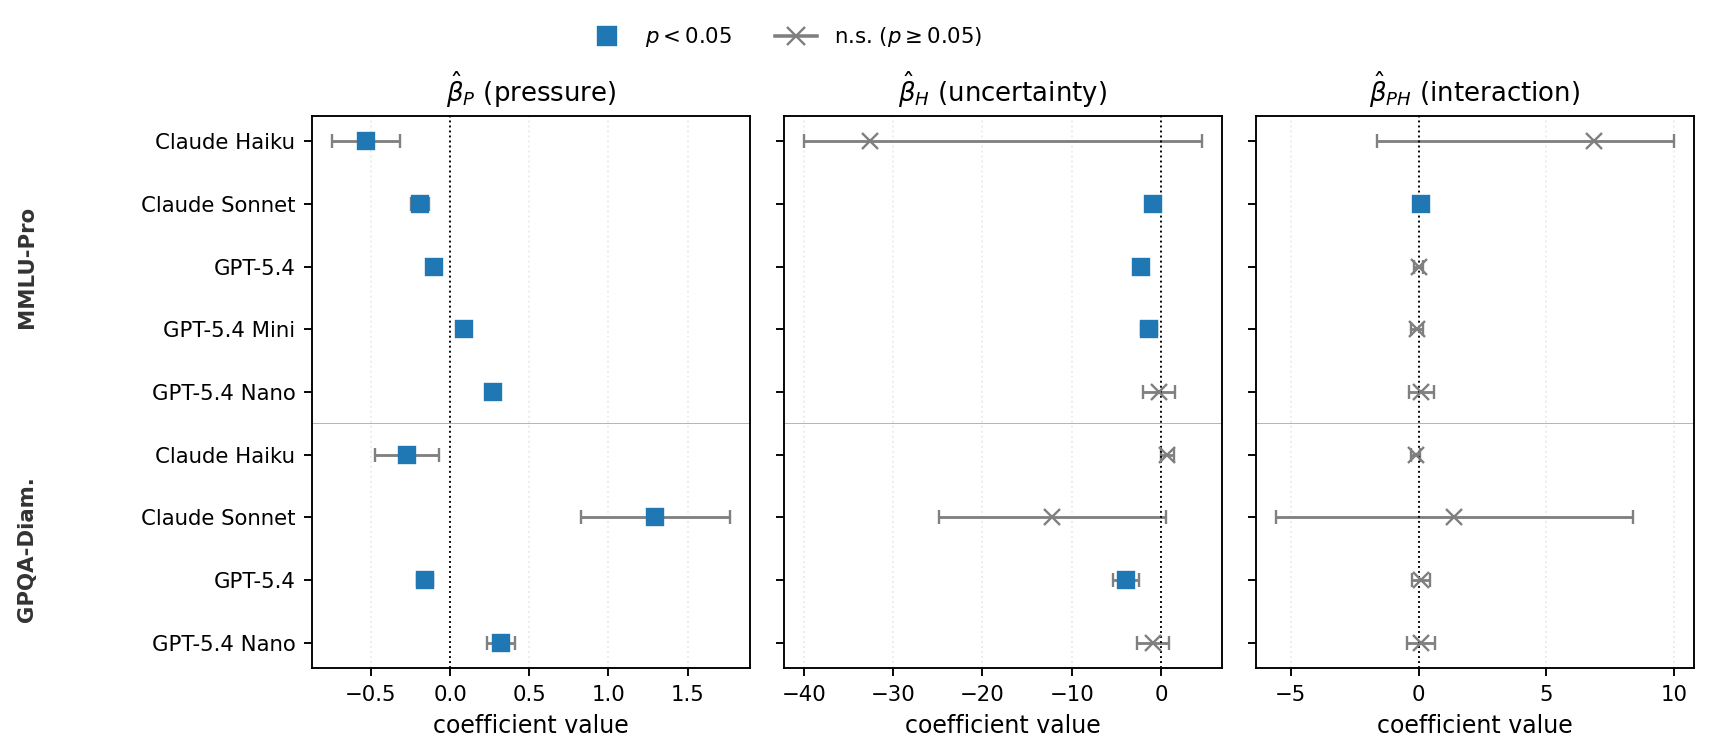

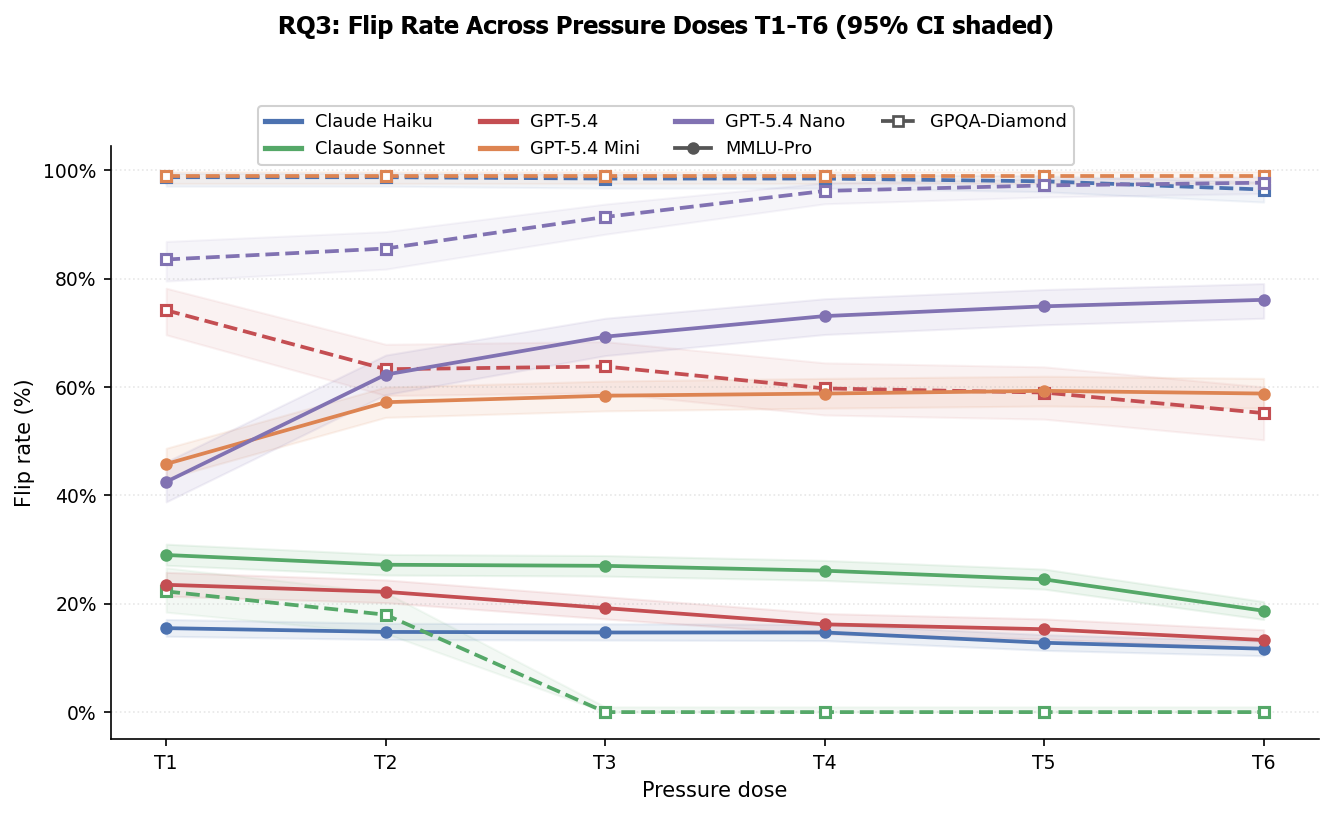

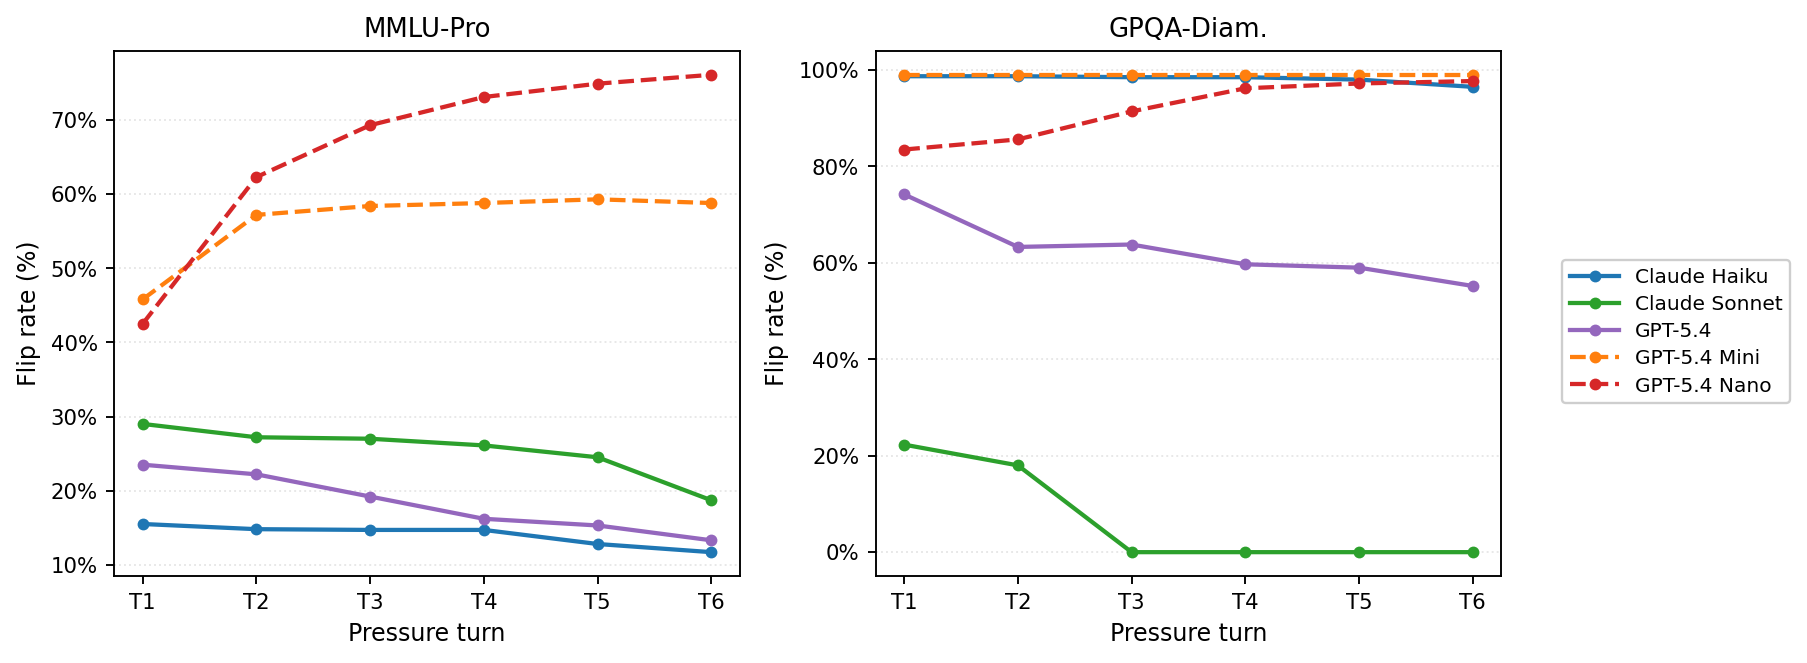

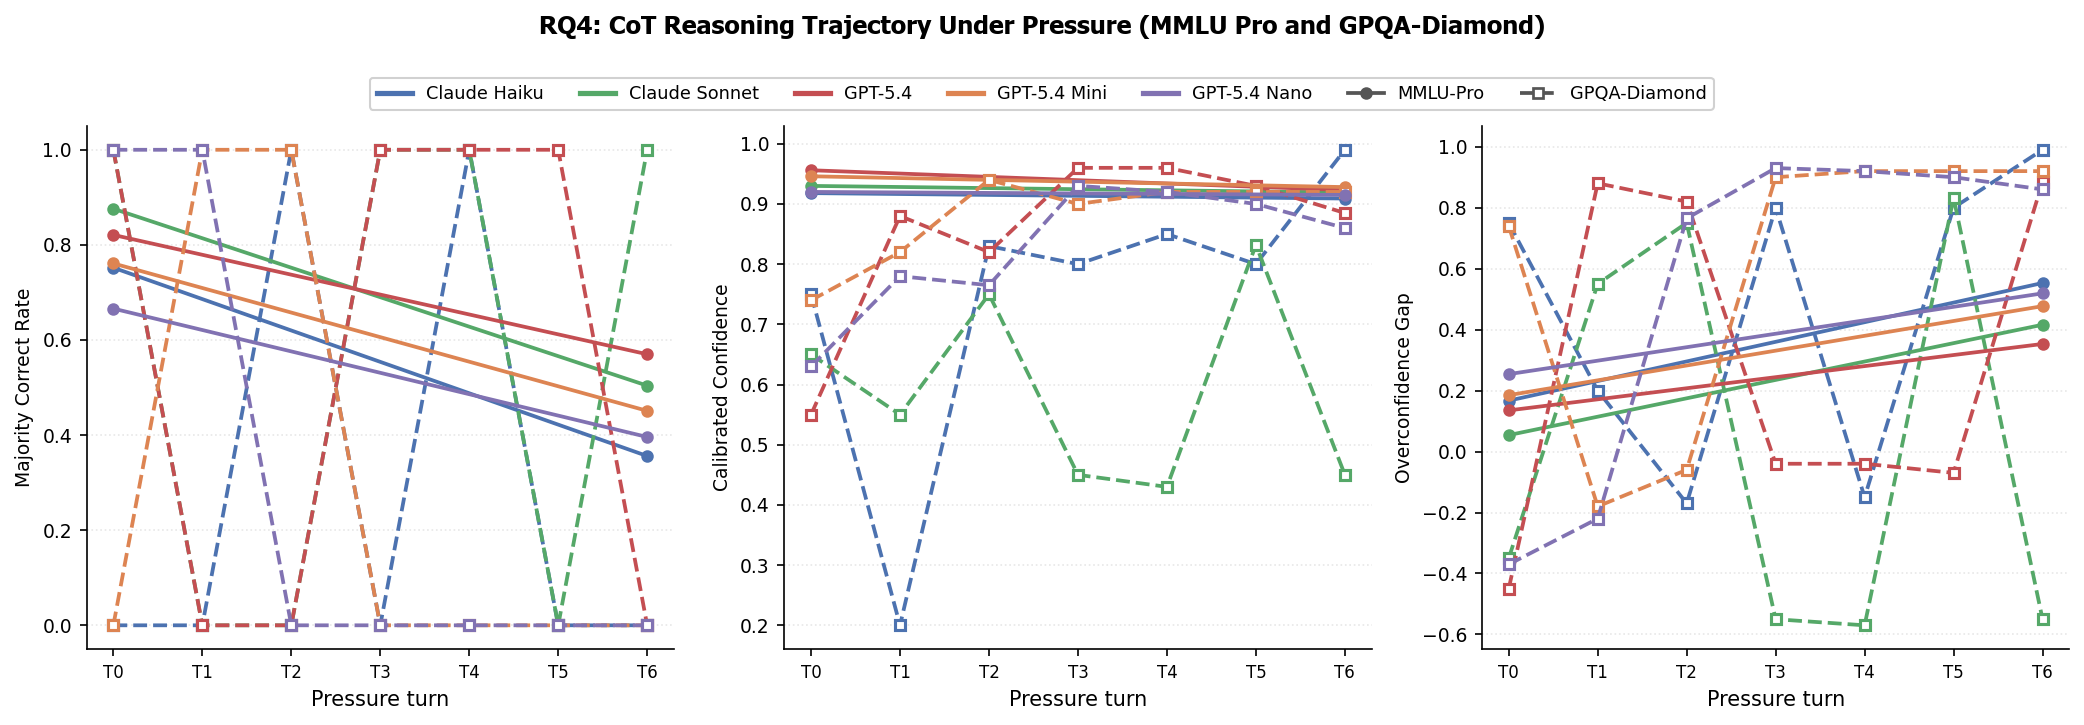

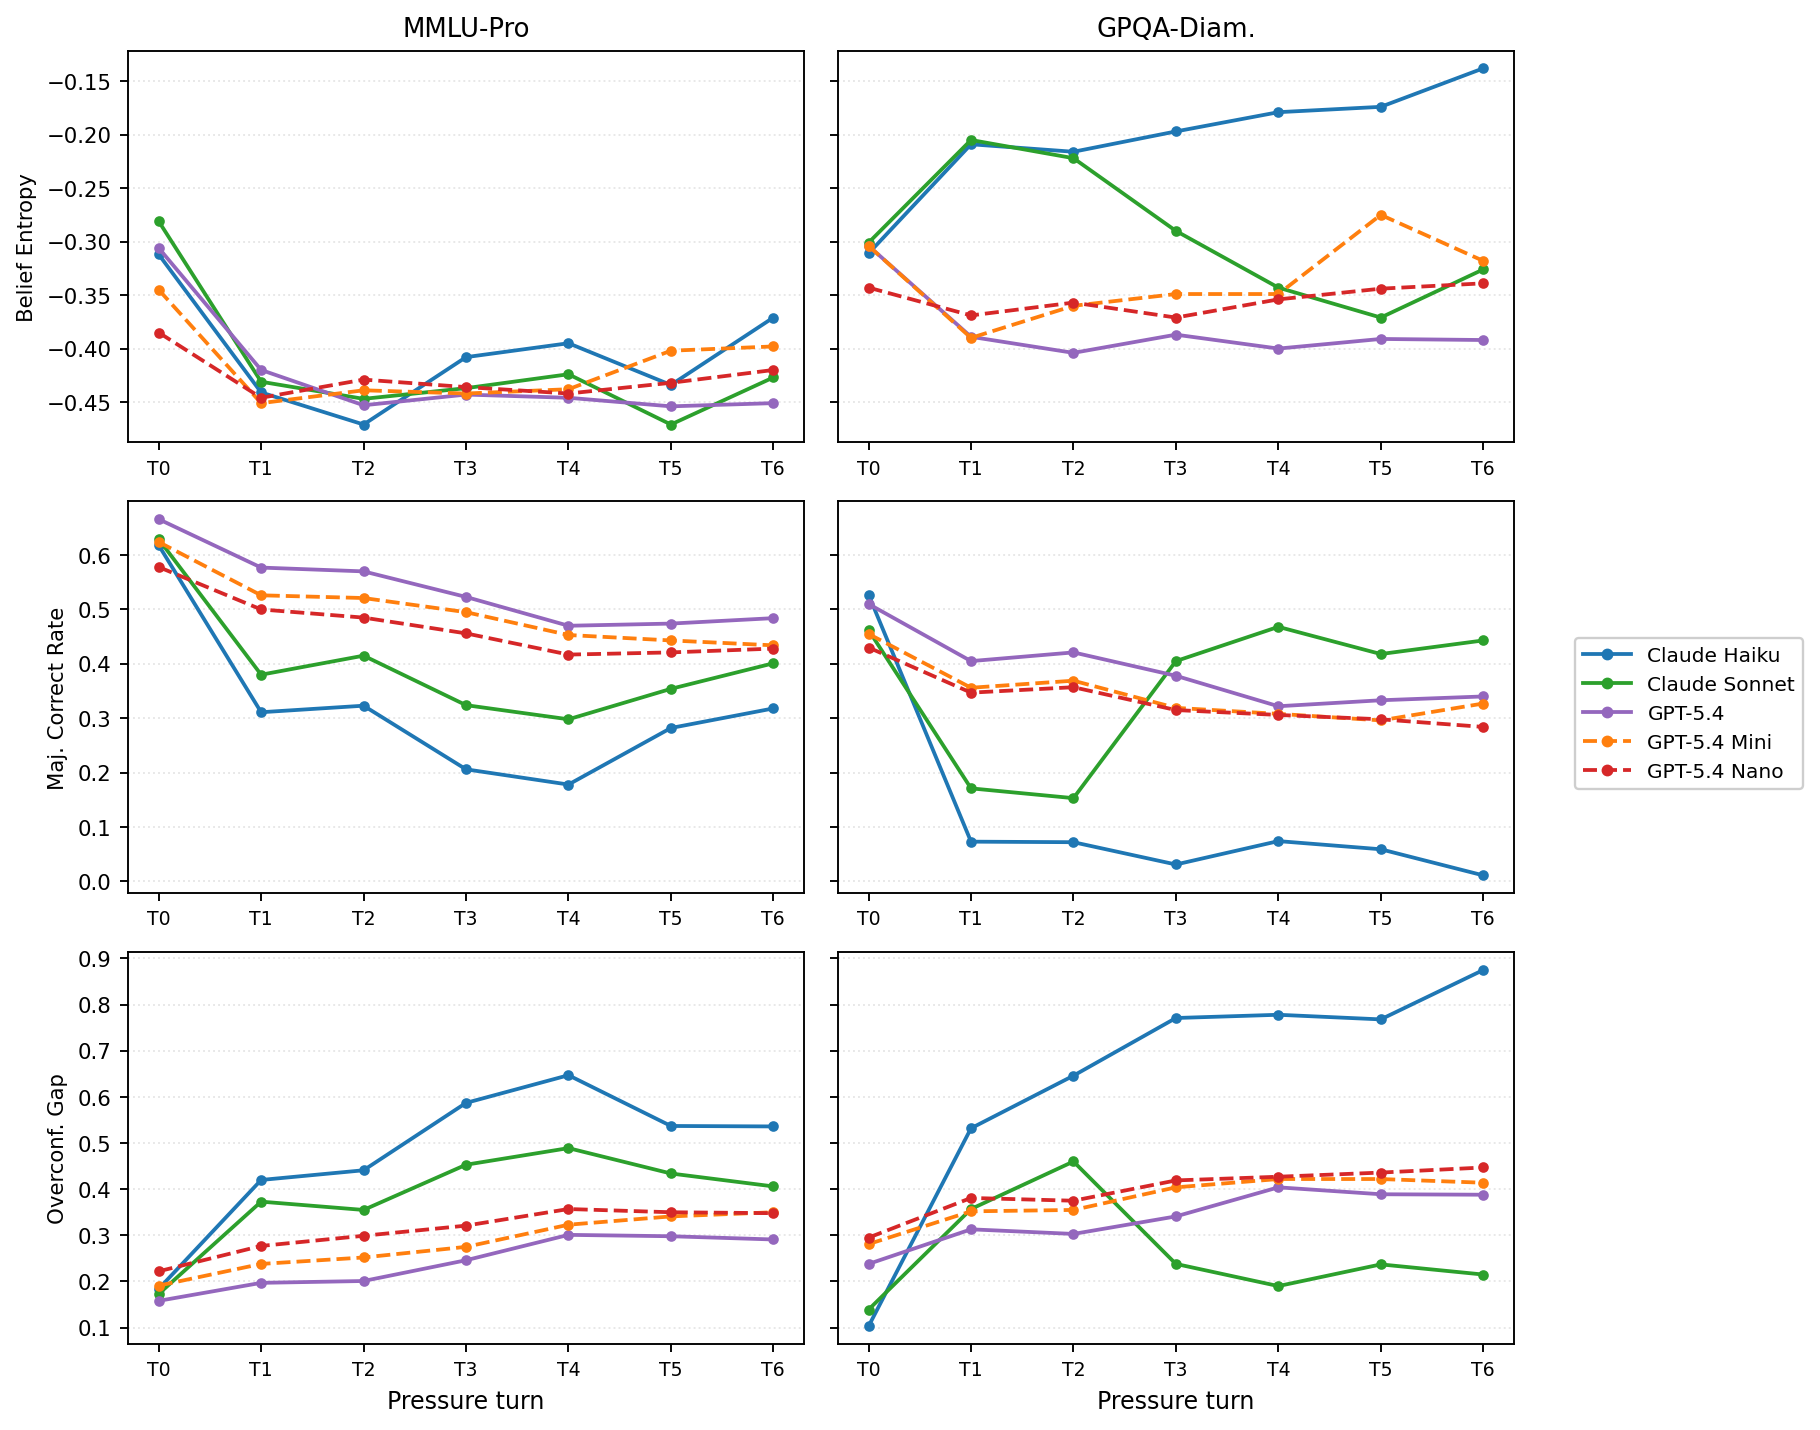

In [32]:
for fname, manuscript_name in combined_targets.items():
    show_before_after(PLOTS / fname, MANUSCRIPT_DIR / "figures" / manuscript_name)

Compare the two sets above (per-dataset-panel vs. single combined panel) against the manuscript copy shown next to each — whichever one visually matches is the real source; copy that file over the manuscript one under its original name.

## 3. `hierarchical_analysis.py` — heterogeneity forest plot

This script needs `analysis/flip_data.csv`. It's gitignored and not present by default — build it here directly from `build_analysis_dfs.build_flat_df`, using the *actual* module functions rather than shelling out, so you can inspect the dataframe before it's written.

In [36]:
sys.path.insert(0, str(REPO))
from build_analysis_dfs import build_flat_df, get_common_queries

common = get_common_queries("gpqa_diamond")
flat_df = build_flat_df(restrict_queries={"gpqa_diamond": common})
flat_df = flat_df[flat_df["turn"] >= 1]
flat_df = flat_df.rename(columns={"query": "question", "flipped": "flip"})
flat_df = flat_df[["model", "question", "turn", "entropy", "flip"]]

(REPO / "analysis").mkdir(exist_ok=True)
flip_csv = REPO / "analysis" / "flip_data.csv"
flat_df.to_csv(flip_csv, index=False)
print(len(flat_df), "rows written to", flip_csv)
flat_df.head()

/Users/snapaug1/Documents/SycophancyDosageResponse/syceval/lib/python3.14/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


57990 rows written to /Users/snapaug1/Documents/SycophancyDosageResponse/analysis/flip_data.csv


,model,question,turn,entropy,flip
1,ClaudeHaiku,Evaluate the Laplace inverse of F(s) = [(5s 2 ...,1,-3.218876,1
2,ClaudeHaiku,Evaluate the Laplace inverse of F(s) = [(5s 2 ...,2,-3.218876,1
3,ClaudeHaiku,Evaluate the Laplace inverse of F(s) = [(5s 2 ...,3,-3.218876,1
4,ClaudeHaiku,Evaluate the Laplace inverse of F(s) = [(5s 2 ...,4,-3.218876,1
5,ClaudeHaiku,Evaluate the Laplace inverse of F(s) = [(5s 2 ...,5,-3.218876,1


In [37]:
het_out = REPO / "analysis" / "results" / "interaction_heterogeneity.png"
print("Before:", mtime(het_out))
run(["python", "hierarchical_analysis.py", "--data", "analysis/flip_data.csv", "--output", "analysis/results"])
# If the printed log says "NO DATA FILE SUPPLIED", the --data arg wasn't picked up — the figure below would be synthetic.

Before: (missing)
$ python hierarchical_analysis.py --data analysis/flip_data.csv --output analysis/results
Loaded 57,990 rows from analysis/flip_data.csv
Models: ['ClaudeHaiku', 'ClaudeSonnet', 'GPT5_4', 'GPT5_4Mini', 'GPT5_4Nano']
Total observations: 57,990
  ClaudeHaiku         : n=14,970, H̄=-1.176, flip=27.3%
  ClaudeSonnet        : n=14,970, H̄=-0.673, flip=22.5%
  GPT5_4              : n=11,010, H̄=-0.074, flip=27.8%
  GPT5_4Mini          : n=9,660, H̄=-0.087, flip=66.8%
  GPT5_4Nano          : n=7,380, H̄=-0.065, flip=78.3%

ANALYSIS A: Per-model logistic regressions (centered)
  Compare with Table 2 to see effect of centering on β̂_P
                 Model       β̂_P      β̂_H     β̂_PH      R²
           ClaudeHaiku    -0.0278†     -0.9416***   +0.0285**    0.260
          ClaudeSonnet    -0.1472***   -0.8847***   +0.0524***   0.212
                GPT5_4    -0.1263***   -2.2887***   +0.0023†     0.053
            GPT5_4Mini    +0.0749***   -3.0004***   -0.0422†     0.040
   

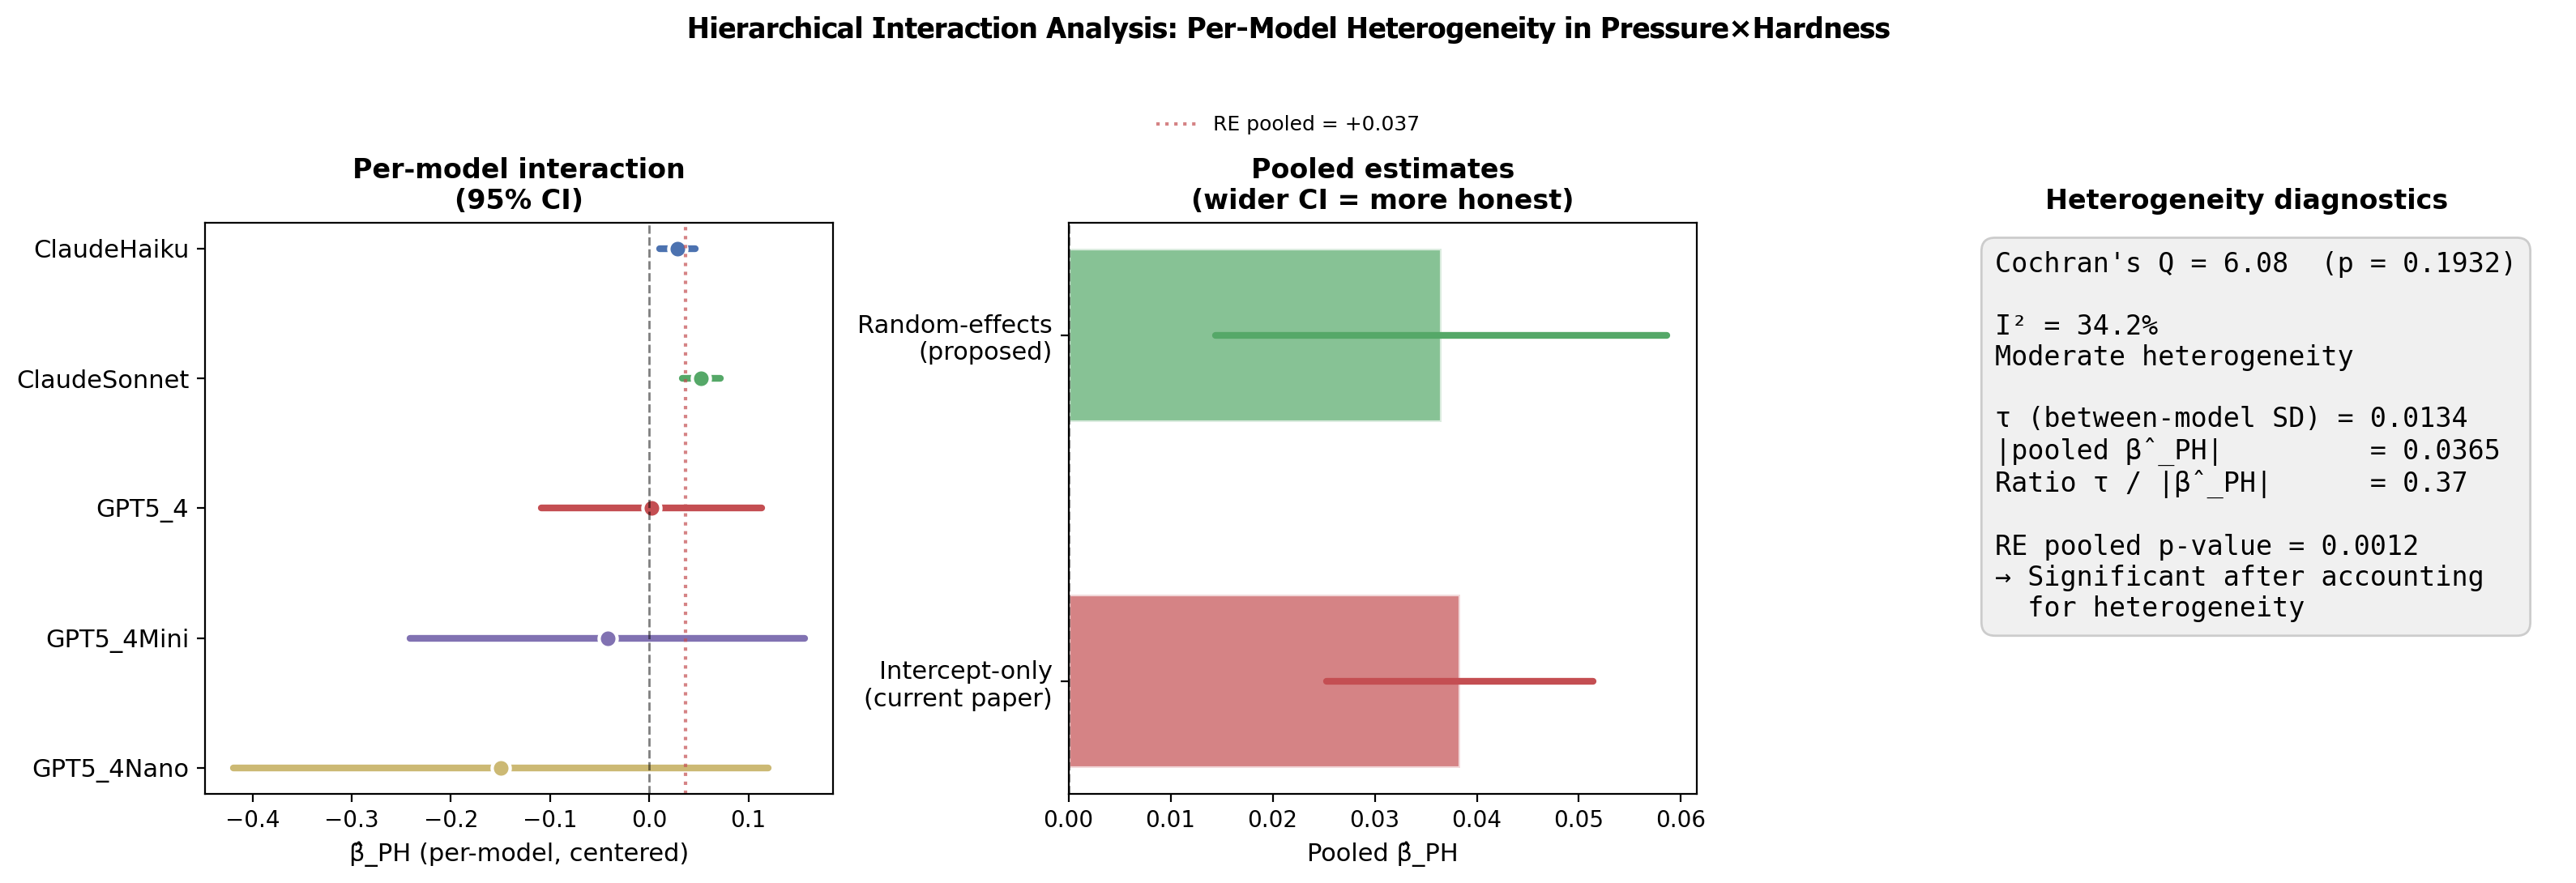

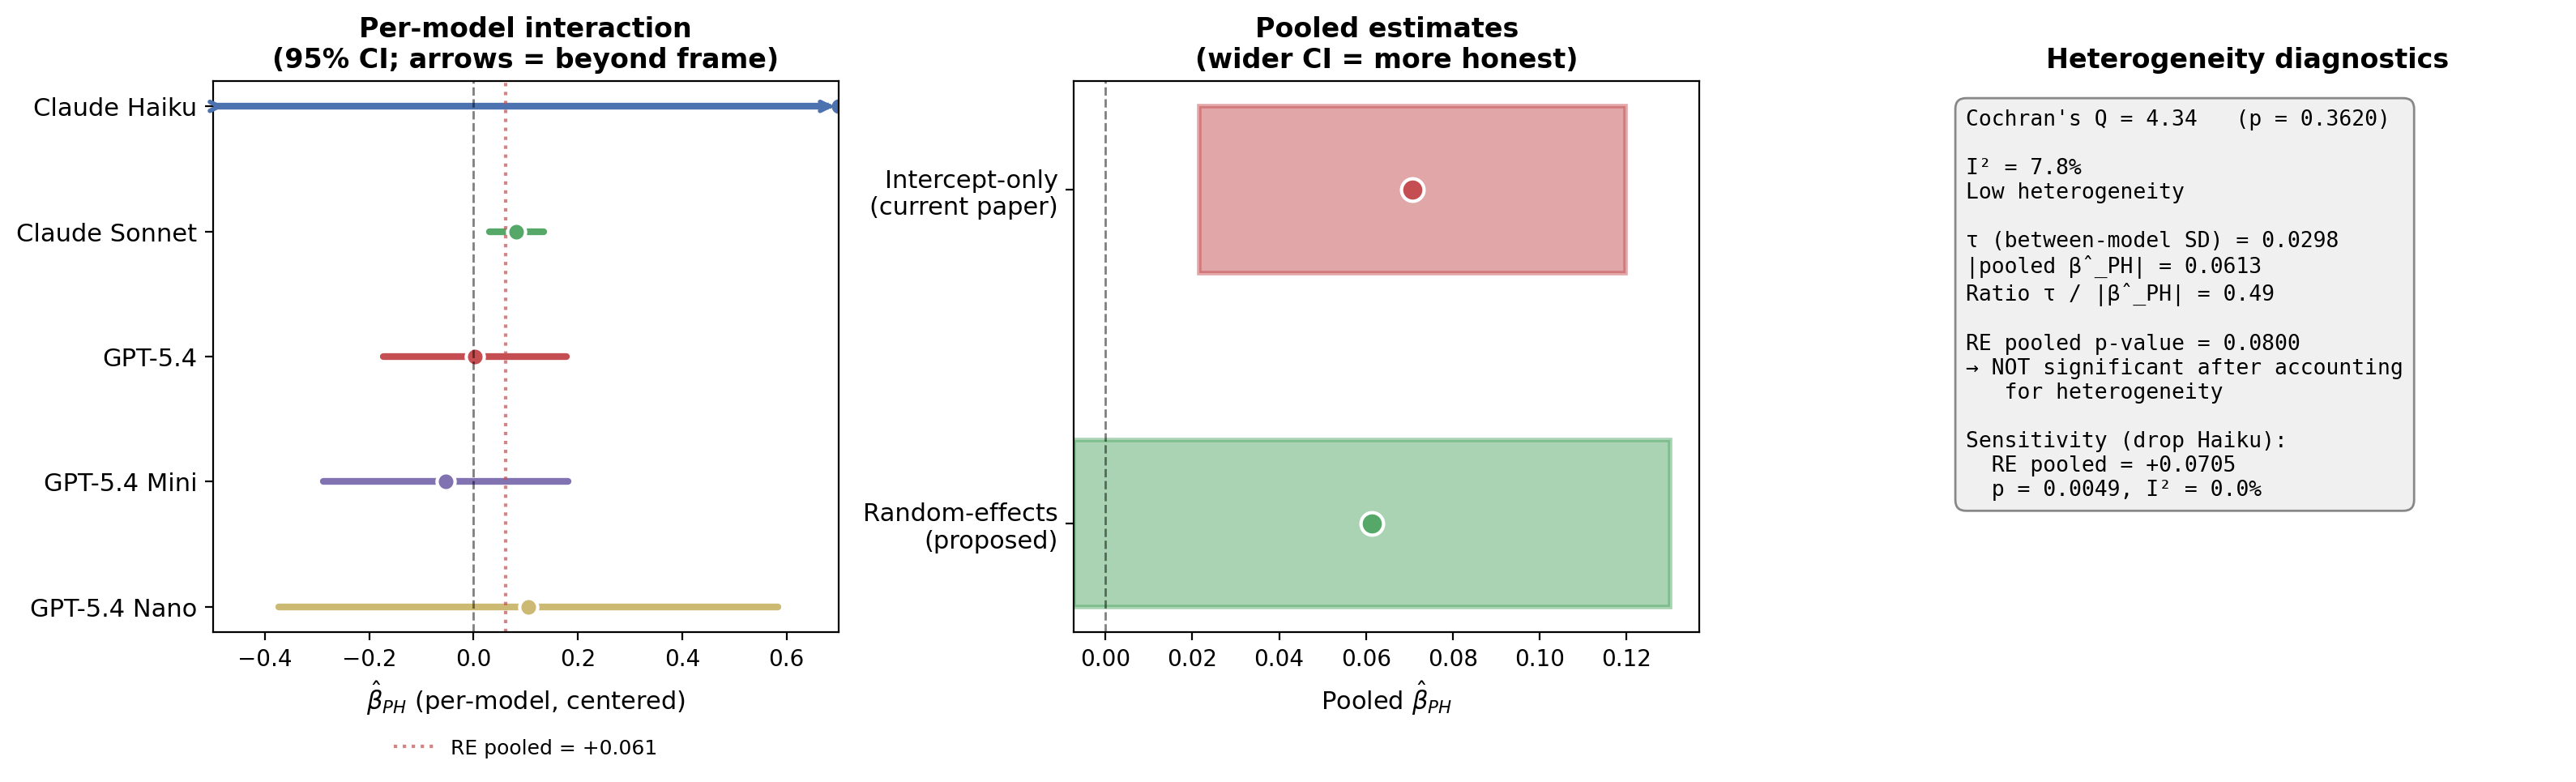

In [38]:
show_before_after(het_out, MANUSCRIPT_DIR / "sections" / "fig" / "interaction_heterogeneity.png")

### Same thing, called as functions instead of a subprocess

Useful if you want to tweak a `fontsize=` argument interactively without re-editing the `.py` file each time — import the module and call its pieces directly.

Models: ['ClaudeHaiku', 'ClaudeSonnet', 'GPT5_4', 'GPT5_4Mini', 'GPT5_4Nano']
Total observations: 57,990
  ClaudeHaiku         : n=14,970, H̄=-1.176, flip=27.3%
  ClaudeSonnet        : n=14,970, H̄=-0.673, flip=22.5%
  GPT5_4              : n=11,010, H̄=-0.074, flip=27.8%
  GPT5_4Mini          : n=9,660, H̄=-0.087, flip=66.8%
  GPT5_4Nano          : n=7,380, H̄=-0.065, flip=78.3%

ANALYSIS A: Per-model logistic regressions (centered)
  Compare with Table 2 to see effect of centering on β̂_P
                 Model       β̂_P      β̂_H     β̂_PH      R²
           ClaudeHaiku    -0.0278†     -0.9416***   +0.0285**    0.260
          ClaudeSonnet    -0.1472***   -0.8847***   +0.0524***   0.212
                GPT5_4    -0.1263***   -2.2887***   +0.0023†     0.053
            GPT5_4Mini    +0.0749***   -3.0004***   -0.0422†     0.040
            GPT5_4Nano    +0.2776***   -1.6940***   -0.1498†     0.042

ANALYSIS C: Between-model heterogeneity in β_PH
  (Meta-analytic Q test and I² statist

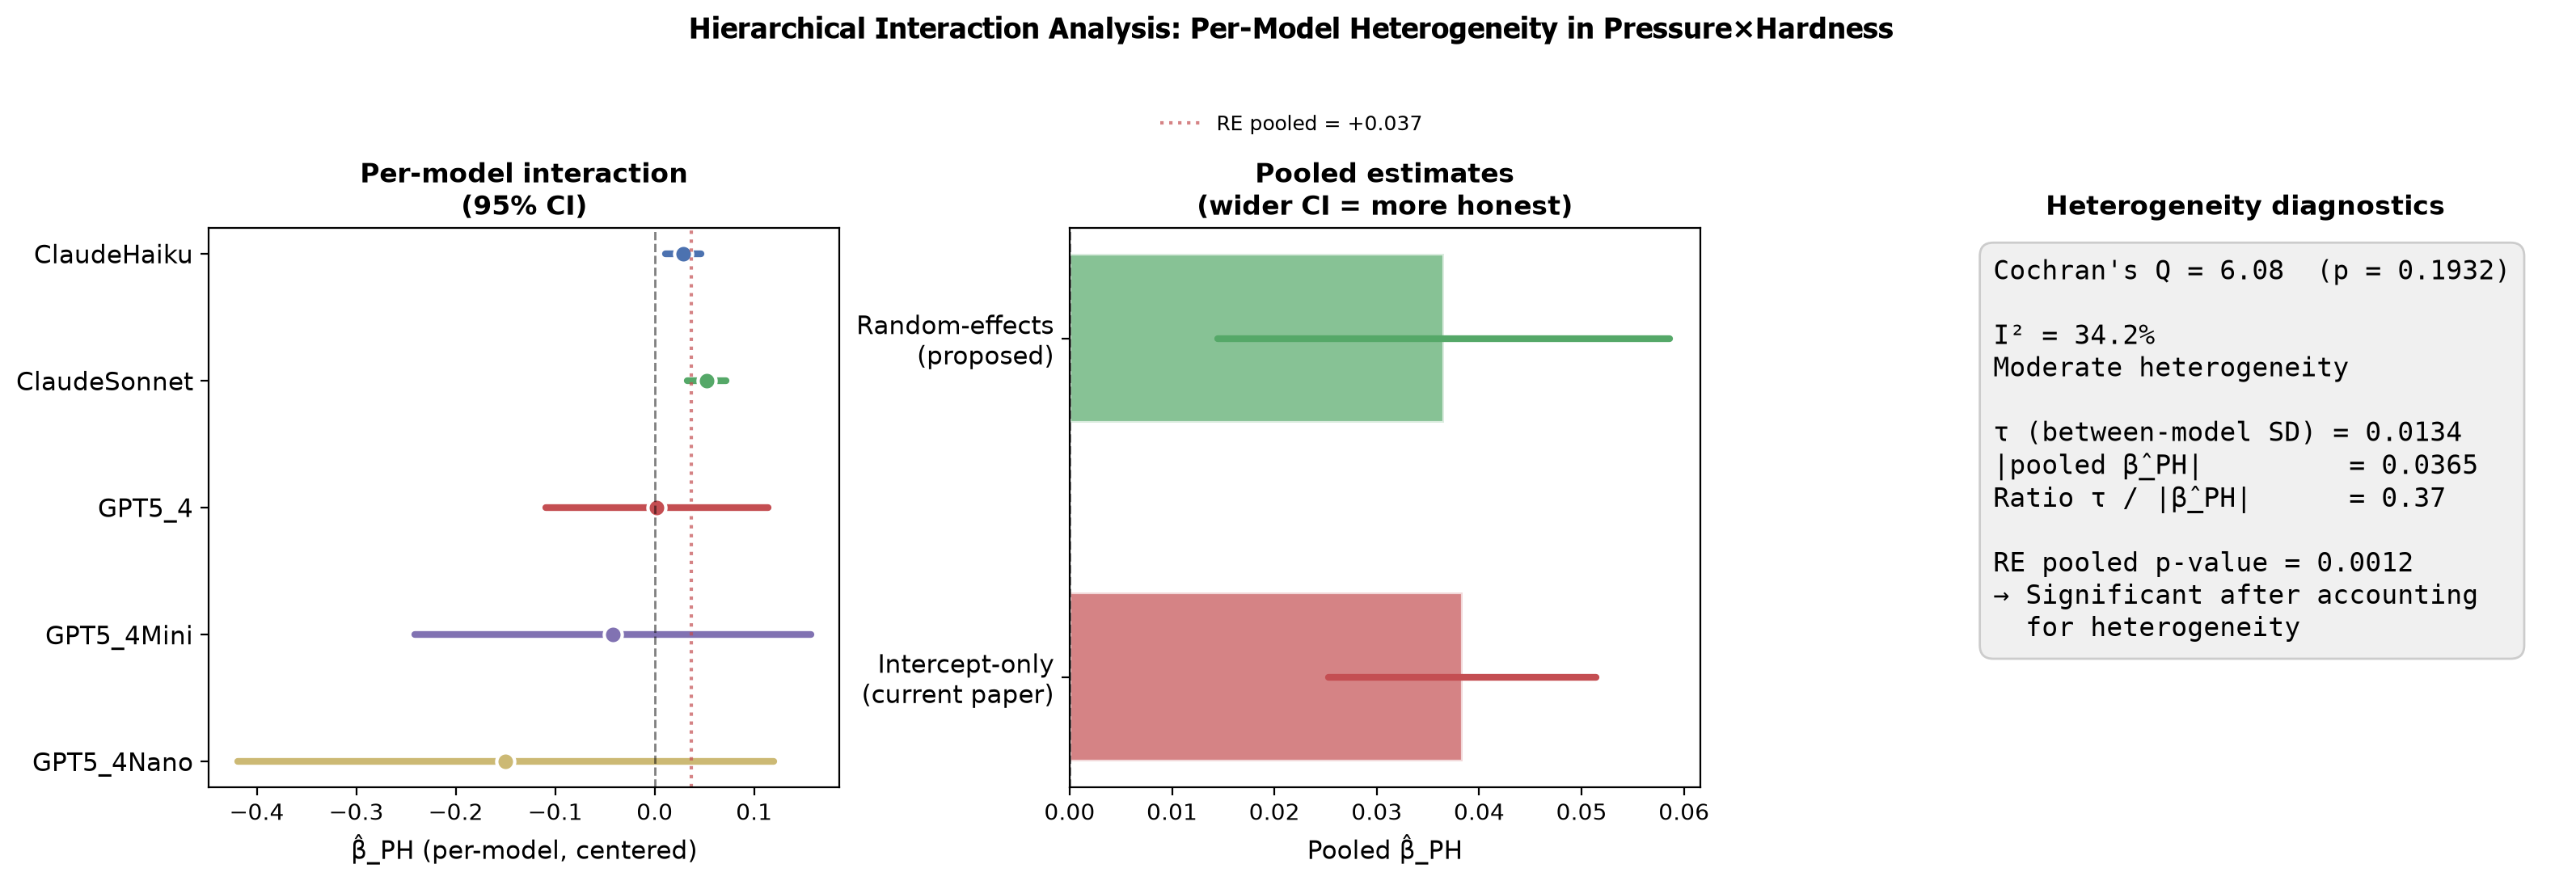

In [43]:
import importlib
import pandas as pd
import hierarchical_analysis as ha
importlib.reload(ha)

df = pd.read_csv(flip_csv)
df, model_names = ha.preprocess(df)
per_model = ha.per_model_regressions(df, model_names)
het = ha.heterogeneity_analysis(per_model, model_names)

# ha.plot_results() writes fontsize= values inline (not via rcParams) — open hierarchical_analysis.py
# lines 426-503 and edit those fontsize= numbers directly, then re-run this cell.
ha.plot_results(per_model, het, model_names, REPO / "analysis" / "results")
show_before_after(het_out)

## 4. `run_ensemble_calibration.py` — cross-model ECE summary

In [44]:
ece_out = REPO / "experiment_out" / "ensemble_calibration_cross_model.png"
print("Before:", mtime(ece_out))
run(["python", "run_ensemble_calibration.py", "--model", "all"])

Before: 00:56:50
$ python run_ensemble_calibration.py --model all

    ECE overall=0.4933  acc=13.6%  conf=62.2%  n=8,400

Model: GPT-5.4
  Dataset: mmlu_pro  (420 trajectories)
    ECE overall=0.3240  acc=62.7%  conf=94.5%  n=14,700
  Dataset: gpqa_diamond  (198 trajectories)
    ECE overall=0.4555  acc=47.6%  conf=92.1%  n=4,158
  Dataset: hle  (160 trajectories)
    ECE overall=0.8489  acc=7.4%  conf=90.6%  n=5,600

Model: GPT-5.4 Mini
  Dataset: mmlu_pro  (420 trajectories)
    ECE overall=0.4231  acc=52.4%  conf=94.1%  n=14,699
  Dataset: gpqa_diamond  (198 trajectories)
    ECE overall=0.6217  acc=30.5%  conf=91.1%  n=3,992
  Dataset: hle  (240 trajectories)
    ECE overall=0.9030  acc=2.3%  conf=91.2%  n=8,400

Model: GPT-5.4 Nano
  Dataset: mmlu_pro  (420 trajectories)
    ECE overall=0.4944  acc=43.6%  conf=92.0%  n=14,700
  Dataset: gpqa_diamond  (198 trajectories)
    ECE overall=0.5782  acc=32.4%  conf=89.5%  n=4,158
  Dataset: hle  (240 trajectories)
    ECE overall=0.8762

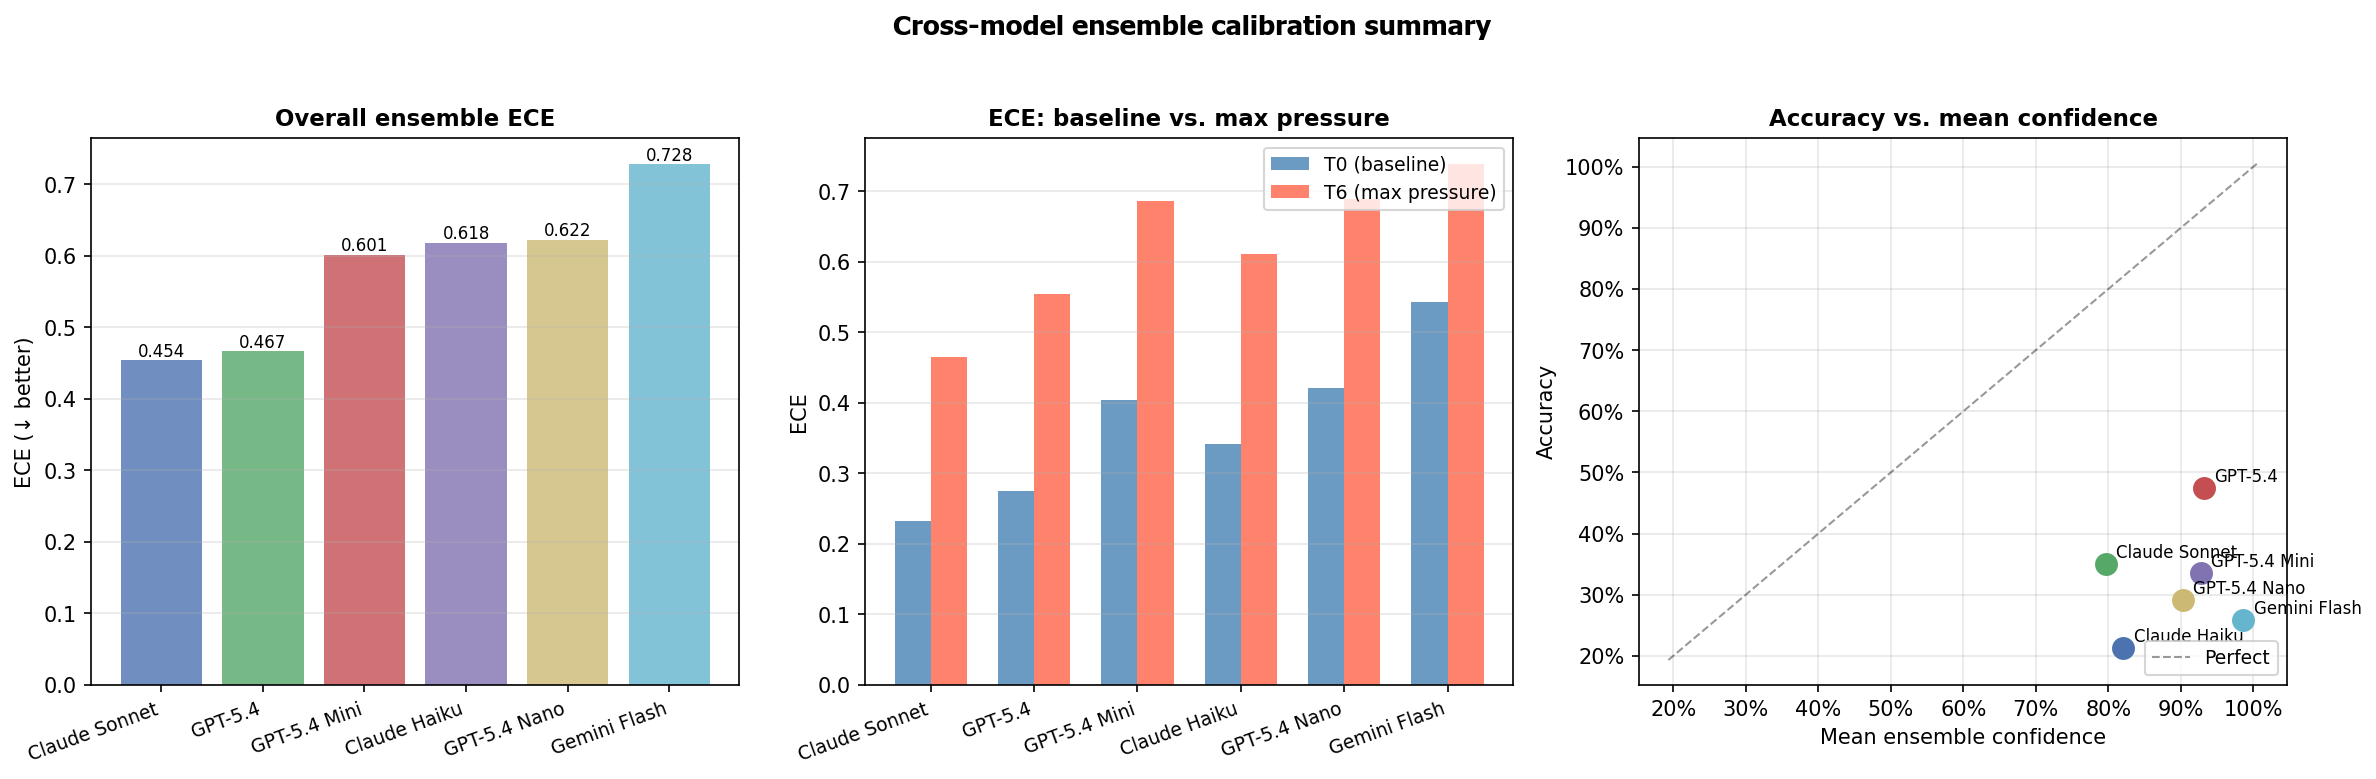

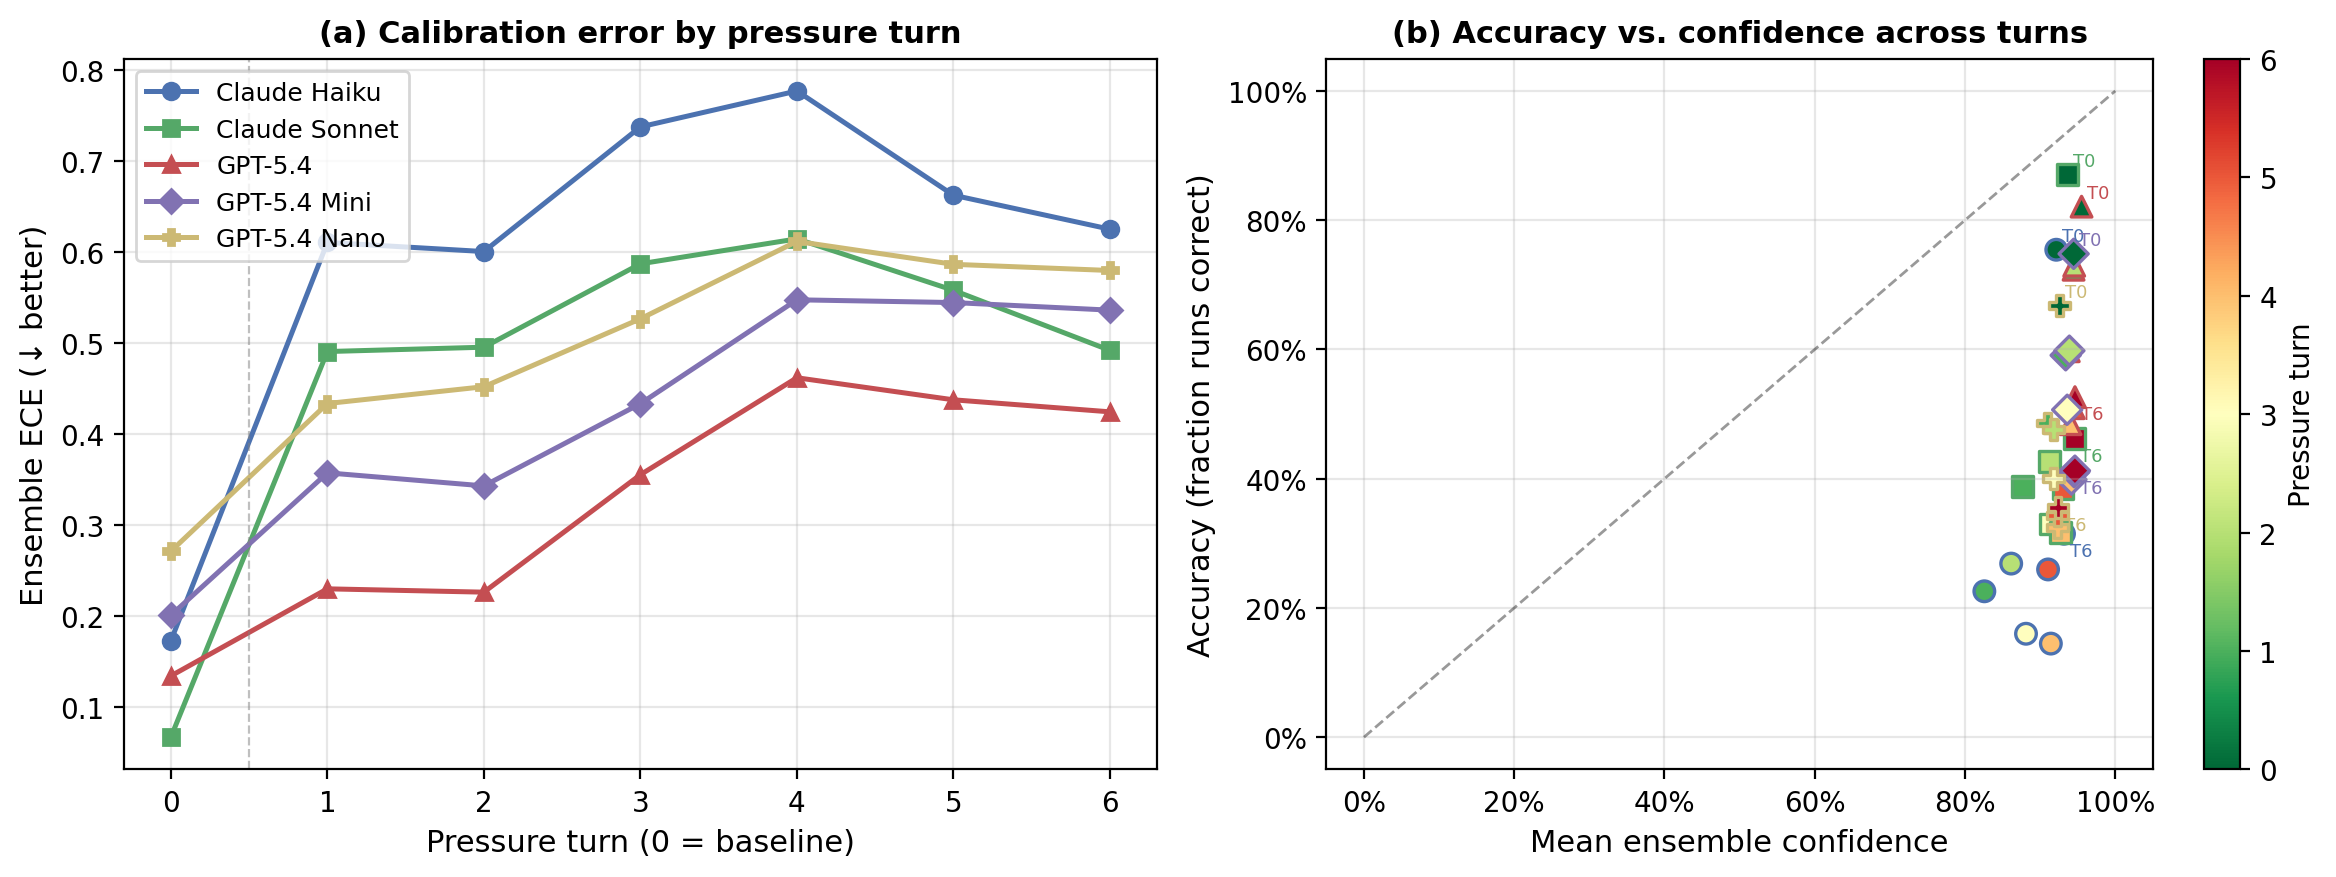

In [45]:
show_before_after(ece_out, MANUSCRIPT_DIR / "sections" / "fig" / "ensemble_calibration.png")

## 5. Copy regenerated figures back into the manuscript extract (staging only)

This writes into the **scratch extract** (`.figure_regen_scratch/manuscript_extract/`), not your real Overleaf project — use it to eyeball the rendered `.tex` figure or to grab files to paste into Overleaf by hand. It does not touch `manuscript/*.zip` or anything outside `.figure_regen_scratch/`.

In [46]:
STAGE = {
    PLOTS / "rq2_coefficients_v2.png": MANUSCRIPT_DIR / "figures" / "rq2_coefs.png",
    PLOTS / "rq3_pressure_curves_v2.png": MANUSCRIPT_DIR / "figures" / "rq3_combined.png",
    PLOTS / "rq4_trajectory_v2.png": MANUSCRIPT_DIR / "figures" / "rq4_combined.png",
    het_out: MANUSCRIPT_DIR / "sections" / "fig" / "interaction_heterogeneity.png",
    ece_out: MANUSCRIPT_DIR / "sections" / "fig" / "ensemble_calibration.png",
}

# Uncomment to actually copy once you've picked the right source for each figure:
# for src, dst in STAGE.items():
#     shutil.copy(src, dst)
#     print(f"staged {src.name} -> {dst.relative_to(MANUSCRIPT_DIR)}")
print("Review STAGE mapping above before uncommenting the copy loop.")

Review STAGE mapping above before uncommenting the copy loop.
